In [78]:
## Step 1: Load the mesh

import trimesh
import numpy as np
import plotly.graph_objects as go

## Define function to visualize the mesh

def visualize_mesh(mesh, extra_details=None, title="Mesh Visualization"):
    traces = [
        go.Mesh3d(
            x=mesh.vertices[:, 0],
            y=mesh.vertices[:, 1],
            z=mesh.vertices[:, 2],
            i=mesh.faces[:, 0],
            j=mesh.faces[:, 1],
            k=mesh.faces[:, 2],
            color='lightgray',
            opacity=0.75,
            name='Mesh'
        )
    ]
    if extra_details is not None:
        if isinstance(extra_details, list):
            traces.extend(extra_details)
        else:
            traces.append(extra_details)
    fig = go.Figure(data=traces)
    fig.update_layout(
        scene=dict(
            xaxis_title='X', yaxis_title='Y', zaxis_title='Z',
            aspectmode='data'
        ),
        title=title
    )
    fig.show()

In [79]:
def find_outer_edge(mesh, smoothing=50, n_slices=100, visualize=True):
    """
    Find the smooth outer edge of a mesh, resembling a C-shape.
    
    Parameters:
    -----------
    mesh : trimesh.Trimesh
        The mesh to analyze
    smoothing : float
        Smoothing factor for the spline fit (higher = smoother)
    n_slices : int
        Number of slices to take along the y-axis
    visualize : bool
        Whether to show a 3D visualization of the result
        
    Returns:
    --------
    outer_points : ndarray
        The smoothed outer edge points (n_points, 3)
    """
    import numpy as np
    from scipy.interpolate import splprep, splev
    from scipy.stats import zscore
    
    # Get mesh vertices
    vertices = mesh.vertices
    x, y, z = vertices[:, 0], vertices[:, 1], vertices[:, 2]
    
    # Slice the mesh along y-axis
    y_min, y_max = y.min(), y.max()
    y_slices = np.linspace(y_min, y_max, n_slices)
    
    # Storage for edge points (x-min and x-max at each slice)
    left_points = []
    right_points = []
    
    for y_val in y_slices:
        # Define window size proportional to y-range and number of slices
        window = 0.2 * (y_max - y_min) / n_slices
        mask = np.abs(y - y_val) < window
        
        if np.sum(mask) < 3:  # Skip slices with too few points
            continue
            
        x_slice = x[mask]
        z_slice = z[mask]
        y_slice = y[mask]
        
        # Detect and remove outliers in x using z-score
        x_scores = np.abs(zscore(x_slice)) if len(x_slice) > 5 else np.zeros_like(x_slice)
        valid_mask = x_scores < 3.0  # Keep points within 3 standard deviations
        
        if np.sum(valid_mask) < 3:  # Skip if too few valid points
            continue
            
        x_slice = x_slice[valid_mask]
        y_slice = y_slice[valid_mask]
        z_slice = z_slice[valid_mask]
        
        # Get min/max x points
        idx_min = np.argmin(x_slice)
        idx_max = np.argmax(x_slice)
        
        left_points.append([x_slice[idx_min], y_slice[idx_min], z_slice[idx_min]])
        right_points.append([x_slice[idx_max], y_slice[idx_max], z_slice[idx_max]])
    
    # Convert to arrays
    left_points = np.array(left_points)
    right_points = np.array(right_points)
    
    # Check if we have enough points
    if len(left_points) < 5 or len(right_points) < 5:
        raise ValueError("Not enough points to create smooth edges. Try increasing n_slices.")
    
    # Fit splines with increased smoothing
    left_tck, left_u = splprep(left_points.T, s=smoothing)
    right_tck, right_u = splprep(right_points.T, s=smoothing)
    
    # Generate smooth curves with more points for better interpolation
    u_dense = np.linspace(0, 1, 200)
    left_curve = np.array(splev(left_u, left_tck)).T
    right_curve = np.array(splev(right_u, right_tck)).T
    
    # Determine which curve is the outer edge (typically the right/max x curve)
    # For a C-shape, the outer edge is usually the one with larger x-coordinate span
    left_x_range = np.max(left_curve[:, 0]) - np.min(left_curve[:, 0])
    right_x_range = np.max(right_curve[:, 0]) - np.min(right_curve[:, 0])
    
    outer_points = right_curve if right_x_range >= left_x_range else left_curve
    
    # Apply final smoothing to ensure a very smooth curve
    tck, u = splprep(outer_points.T, s=smoothing * 1.5)
    outer_points = np.array(splev(u, tck)).T
    
    return outer_points

In [80]:
## Find the midpoint of the smooth outer points, and take a cross section at that point

def get_midpoint_trace(outer_points, mesh):

    # Find the midpoint of the smooth outer points
    mid_idx = len(outer_points) // 2
    midpoint = outer_points[mid_idx]

    # Estimate tangent at the midpoint (using neighbors)
    tangent = outer_points[mid_idx + 1] - outer_points[mid_idx - 1]
    tangent /= np.linalg.norm(tangent)

    # Take a cross section at the midpoint
    section = mesh.section(plane_origin=midpoint, plane_normal=tangent)

    # Get section points
    if section is not None:
        if hasattr(section, 'discrete'):
            section_points = np.vstack([seg for seg in section.discrete])
        else:
            section_points = section.vertices

       
        midpoint_trace = go.Scatter3d(
            x=[midpoint[0]], y=[midpoint[1]], z=[midpoint[2]],
            mode='markers', marker=dict(size=8, color='black'), name='Midpoint'
        )

        section_trace = go.Scatter3d(
            x=section_points[:, 0], y=section_points[:, 1], z=section_points[:, 2],
            mode='markers', marker=dict(size=5, color='orange'), name='Midpoint Cross Section'
        )
        return midpoint_trace, section_trace, section_points
    else:
        print("No cross section found at midpoint.")

In [81]:
def create_projected_curve(mesh, outer_points, smooth=50, n_points=120, end_segment_size=10):
    """
    Create a curve that extends to the minimum x boundaries of the cell with 
    parallel end segments perpendicular to circle axes.
    """
    from scipy.interpolate import splprep, splev, CubicSpline
    import numpy as np
    
    # 1. Fit spline to original curve
    tck, u = splprep(outer_points.T, s=smooth)
    
    # 2. Make a copy of the input points for the central part
    central_curve = outer_points.copy()
    
    # 3. Find the min x value in the mesh (with a small buffer)
    min_x = mesh.vertices[:, 0].min() + 0.5  # Add a small buffer to avoid edge cases
    max_x = mesh.vertices[:, 0].max() - 0.5  # Add a small buffer to avoid edge cases
    
    # 4. Find mesh vertices near minimum x
    x_tol = 2.0  # Tolerance for considering points at minimum x
    near_min_x = mesh.vertices[np.abs(mesh.vertices[:, 0] - min_x) < x_tol]

    if len(near_min_x) > 0:
        # 5. For the start point: find the minimum x point with closest y-coordinate
        start_pt = outer_points[0]
        y_diffs_start = np.abs(near_min_x[:, 1] - start_pt[1])
        start_candidate_idx = np.argmin(y_diffs_start)
        start_boundary = near_min_x[start_candidate_idx]
        
        # 6. For the end point: find the minimum x point with closest y-coordinate
        end_pt = outer_points[-1]
        y_diffs_end = np.abs(near_min_x[:, 1] - end_pt[1])
        end_candidate_idx = np.argmin(y_diffs_end)
        end_boundary = near_min_x[end_candidate_idx]
        
        # 7. Create new curve with these endpoints
        extended_curve = np.vstack([start_boundary, central_curve, end_boundary])
    else:
        # Fallback to original curve if no min x points found
        extended_curve = central_curve
    
    # 8. Project onto mesh surface to ensure all points are on the mesh
    extended_curve = trimesh.proximity.closest_point(mesh, extended_curve)[0]
    
    # 9. Resample for smoothness with higher density at ends
    if len(extended_curve) >= 3:
        t = np.linspace(0, 1, len(extended_curve))
        t_new = np.linspace(0, 1, n_points)
        
        # Use cubic interpolation to maintain shape
        cs_x = CubicSpline(t, extended_curve[:,0])
        cs_y = CubicSpline(t, extended_curve[:,1])
        cs_z = CubicSpline(t, extended_curve[:,2])
        
        final_curve = np.column_stack([
            cs_x(t_new), cs_y(t_new), cs_z(t_new)
        ])
        
        # Ensure endpoints are exactly preserved
        final_curve[0] = extended_curve[0]
        final_curve[-1] = extended_curve[-1]
    else:
        # Fall back to original method if insufficient points
        tck2, u2 = splprep(extended_curve.T, s=smooth)
        final_curve = np.array(splev(np.linspace(0, 1, n_points), tck2)).T
    
    # 10. Apply additional smoothing
    tck3, u3 = splprep(final_curve.T, s=smooth*0.5)  # Use lighter smoothing to preserve shape
    final_curve_smooth = np.array(splev(np.linspace(0, 1, n_points), tck3)).T
    
    # 11. Make end segments parallel and perpendicular to circle axes
    # We assume the Y axis is the main axis of the circles based on code
    
    # Number of points to adjust at each end
    if end_segment_size > n_points // 4:
        end_segment_size = n_points // 4  # Limit to 1/4 of total points
    
    # Get tangent directions at the transition points
    start_transition_idx = end_segment_size
    end_transition_idx = n_points - end_segment_size - 1
    
    start_tangent = final_curve_smooth[start_transition_idx+1] - final_curve_smooth[start_transition_idx-1]
    end_tangent = final_curve_smooth[end_transition_idx+1] - final_curve_smooth[end_transition_idx-1]
    
    # Normalize tangents
    start_tangent = start_tangent / np.linalg.norm(start_tangent)
    end_tangent = end_tangent / np.linalg.norm(end_tangent)
    
    # Create vectors perpendicular to Y axis (in X-Z plane)
    # These will form the direction of our end segments
    y_axis = np.array([0, 1, 0])
    
    # For start segment: Project start_tangent to be perpendicular to Y
    start_dir = start_tangent - np.dot(start_tangent, y_axis) * y_axis
    start_dir = start_dir / np.linalg.norm(start_dir)
    
    # For end segment: Project end_tangent to be perpendicular to Y
    end_dir = end_tangent - np.dot(end_tangent, y_axis) * y_axis
    end_dir = end_dir / np.linalg.norm(end_dir)
    
    # Adjust the start segment points
    for i in range(end_segment_size):
        # Transition factor (0 at transition point, 1 at endpoint)
        factor = (end_segment_size - i) / end_segment_size
        # Original direction from transition point to current point
        orig_dir = final_curve_smooth[i] - final_curve_smooth[start_transition_idx]
        dist = np.linalg.norm(orig_dir)
        # New position using start_dir, preserving distance
        final_curve_smooth[i] = final_curve_smooth[start_transition_idx] - dist * start_dir * factor
    
    # Adjust the end segment points
    for i in range(end_segment_size):
        idx = n_points - i - 1  # Count from the end
        # Transition factor (0 at transition point, 1 at endpoint)
        factor = (end_segment_size - i) / end_segment_size
        # Original direction from transition point to current point
        orig_dir = final_curve_smooth[idx] - final_curve_smooth[end_transition_idx]
        dist = np.linalg.norm(orig_dir)
        # New position using end_dir, preserving distance
        final_curve_smooth[idx] = final_curve_smooth[end_transition_idx] + dist * end_dir * factor
    
    # 12. Project back onto mesh surface
    final_curve_smooth = trimesh.proximity.closest_point(mesh, final_curve_smooth)[0]
    
    # 13. Apply one final light smoothing to blend the adjusted ends
    tck4, u4 = splprep(final_curve_smooth.T, s=smooth*0.3)
    final_curve_smooth = np.array(splev(np.linspace(0, 1, n_points), tck4)).T
    
    # Ensure endpoints remain fixed
    final_curve_smooth[0] = final_curve[0]
    final_curve_smooth[-1] = final_curve[-1]
    
    return final_curve_smooth

In [82]:
from scipy.spatial import ConvexHull
from sklearn.decomposition import PCA

def define_end_point_circles(outer_curve_projected, section_points):

    def cross_section_area_2d(points):
        pca = PCA(n_components=2)
        points_2d = pca.fit_transform(points)
        hull = ConvexHull(points_2d)
        return hull.volume

    # Calculate area and radius
    area_mid = cross_section_area_2d(section_points)
    radius = np.sqrt(area_mid / np.pi)

    # Get endpoints of the projected outer curve
    start_pt = outer_curve_projected[0]
    end_pt = outer_curve_projected[-1]

    def make_circle_y(center, radius, n_points=50, y_offset=0):
        # Circle normal is Y axis, so circle lies in XZ plane
        angles = np.linspace(0, 2*np.pi, n_points)
        circle = np.zeros((n_points, 3))
        circle[:, 0] = center[0]   # X
        circle[:, 1] = center[1] + y_offset + radius * np.cos(angles)                         # Y (fixed)
        circle[:, 2] = center[2] + radius * np.sin(angles)  # Z
        return circle

    # Create circles at start and end, parallel to Y axis
    circle_start = make_circle_y(start_pt, radius, y_offset=radius)
    circle_end = make_circle_y(end_pt, radius, y_offset=-radius)

    # Plot mesh, projected outer curve, and circles
    circle_start_trace = go.Scatter3d(
        x=circle_start[:,0], y=circle_start[:,1], z=circle_start[:,2],
        mode='lines', line=dict(color='red', width=6), name='Start Circle'
    )
    circle_end_trace = go.Scatter3d(
        x=circle_end[:,0], y=circle_end[:,1], z=circle_end[:,2],
        mode='lines', line=dict(color='blue', width=6), name='End Circle'
    )
    outer_projected_trace = go.Scatter3d(
        x=outer_curve_projected[:,0], y=outer_curve_projected[:,1], z=outer_curve_projected[:,2],
        mode='lines+markers', marker=dict(size=4, color='green'), name='Outer Curve Projected'
    )

    ## Find and return the circle centres
    def find_circle_center(circle):
        # Find the average of all coordinates for the true center
        return np.mean(circle, axis=0)
    center_start = find_circle_center(circle_start)
    center_end = find_circle_center(circle_end)
    # Plot the centers
    center_start_trace = go.Scatter3d(
        x=[center_start[0]], y=[center_start[1]], z=[center_start[2]],
        mode='markers', marker=dict(size=8, color='red'), name='Start Circle Center'
    )
    center_end_trace = go.Scatter3d(
        x=[center_end[0]], y=[center_end[1]], z=[center_end[2]],
        mode='markers', marker=dict(size=8, color='blue'), name='End Circle Center'
    )

    return circle_start_trace, circle_end_trace, outer_projected_trace, center_start_trace, center_end_trace, center_start, center_end


In [83]:
def create_bezier_centreline(center_start, section_midpoint, center_end, curve_points=50):
    """
    Create a centreline using a cubic Bezier curve that exactly passes through
    the start, the specified midpoint (at t=0.5), and the end point,
    while keeping the control handles aligned toward the midpoint direction.

    Parameters:
    -----------
    center_start : ndarray
        Center of the start circle (3,)
    section_midpoint : ndarray
        Midpoint of the cross section to interpolate (3,)
    center_end : ndarray
        Center of the end circle (3,)
    curve_points : int
        Number of sample points along the Bezier curve

    Returns:
    --------
    centreline : ndarray
        The fitted centreline points (curve_points, 3)
    centreline_trace : go.Scatter3d
        Plotly trace of the centreline
    """
    import numpy as np
    import plotly.graph_objects as go

    # Ensure floats for arithmetic
    P0 = np.array(center_start, dtype=float)
    M  = np.array(section_midpoint, dtype=float)
    P3 = np.array(center_end, dtype=float)

    # Compute exact handle_sum so that B(0.5) == M
    handle_sum = (8 * M - P0 - P3) / 3.0

    # Compute primary direction from P0 toward midpoint (project off Y)
    y_axis = np.array([0, 1, 0], dtype=float)
    dir_to_mid = M - P0
    dir_to_mid -= np.dot(dir_to_mid, y_axis) * y_axis
    if np.linalg.norm(dir_to_mid) > 1e-6:
        dir_to_mid /= np.linalg.norm(dir_to_mid)
    # Place P1 along this direction, with length = 2/3 of chord length
    length_P1 = 2.0 / 3.0 * np.linalg.norm(M - P0)
    P1 = P0 + dir_to_mid * length_P1

    # Derive P2 so the handles still sum correctly
    P2 = handle_sum - P1

    # Parameterize t and build the curve
    t = np.linspace(0.0, 1.0, curve_points)[:, None]
    centreline = ((1 - t)**3) * P0 \
               + 3 * ((1 - t)**2) * t * P1 \
               + 3 * (1 - t) * (t**2) * P2 \
               + (t**3) * P3

    # Build Plotly 3D trace
    centreline_trace = go.Scatter3d(
        x=centreline[:, 0],
        y=centreline[:, 1],
        z=centreline[:, 2],
        mode='lines+markers',
        marker=dict(size=4),
        line=dict(width=3),
        name='Bezier Centreline'
    )

    return centreline, centreline_trace


In [84]:
import numpy as np
import trimesh
from sklearn.decomposition import PCA

def align_mesh_to_y_axis(mesh):
    """
    Aligns the mesh so its longest principal axis is parallel to the Y-axis,
    and then centers the mesh at the origin.

    This standardizes the mesh's orientation for consistent analysis.

    Parameters:
    -----------
    mesh : trimesh.Trimesh
        The input mesh.

    Returns:
    --------
    aligned_mesh : trimesh.Trimesh
        A new mesh, rotated and centered.
    """
    # 1. Use PCA on the vertices to find the principal axes
    pca = PCA(n_components=3)
    pca.fit(mesh.vertices)
    
    # The first component corresponds to the longest axis
    longest_axis = pca.components_[0]
    
    # The target axis is the world Y-axis
    y_axis = np.array([0, 1, 0])

    # 2. Find the 4x4 transformation matrix that aligns the longest axis with the Y-axis
    transform_matrix = trimesh.geometry.align_vectors(longest_axis, y_axis)

    # 3. Apply the transformation to a copy of the mesh to avoid modifying the original
    aligned_mesh = mesh.copy()
    aligned_mesh.apply_transform(transform_matrix)
    
    # 4. Center the aligned mesh at the origin for consistency
    aligned_mesh.vertices -= aligned_mesh.centroid

    return aligned_mesh

In [85]:
def extract_cross_section_data(file_index=0, side="single_a", n_sections=20):
    """
    Extract cross-section data from a mesh without creating visualizations.
    
    Parameters:
    -----------
    file_index : int
        Index of the file to analyze from the files list
    side : str
        Side to analyze ("single_a" or "single_b")
    n_sections : int
        Number of cross-sections to generate along the centreline
        
    Returns:
    --------
    data : dict
        Dictionary containing all computed data
    """
    from sklearn.decomposition import PCA
    from skimage.measure import EllipseModel
    
    # Select file
    file = files[file_index]
    
    # Initialize results dictionary
    results = {
        'file_info': {
            'file_name': file,
            'side': side,
            'mesh_path': f"{path}{file}/{file}_{side}.obj"
        },
        'mesh_data': {},
        'cross_sections': {
            'indices': [],
            '3d_points': [],
            '2d_points': [],
            'pca_components': [],
            'std_devs': [],
            'aspect_ratios': [],
            'ellipse_fits': []
        }
    }
    
    # Load and process mesh
    mesh_path = results['file_info']['mesh_path']
    mesh = trimesh.load(mesh_path, process=True)
    
    # Align the mesh to the Y-axis and center it
    mesh = align_mesh_to_y_axis(mesh)
    
    # Ensure consistent orientation
    outer_points_check = find_outer_edge(mesh, smoothing=50)
    if np.mean(outer_points_check[:, 0]) < 0:
        mesh.vertices[:, 0] *= -1
    
    # Process mesh to find centreline
    outer_points = find_outer_edge(mesh, smoothing=50)
    outer_curve_projected = create_projected_curve(
        mesh, outer_points, smooth=50, n_points=120, end_segment_size=10
    )

    # Get midpoint cross-section
    _, _, section_points = get_midpoint_trace(outer_points, mesh)

    # Get the circle centers
    _, _, _, _, _, center_start, center_end = define_end_point_circles(outer_curve_projected, section_points)

    # Create the centreline using the actual circle centers
    section_midpoint = np.mean(section_points, axis=0)
    centreline, _ = create_bezier_centreline(
        center_start, section_midpoint, center_end, curve_points=50
    )

    # Store centreline in results
    results['mesh_data']['centreline'] = centreline
    results['mesh_data']['outer_points'] = outer_points
    results['mesh_data']['outer_curve_projected'] = outer_curve_projected
    
    # Define cross-section indices
    end_margin_points = 3  # Avoid unstable sections at the very ends
    start_index = end_margin_points
    end_index = len(centreline) - 1 - end_margin_points
    indices = np.linspace(start_index, end_index, n_sections, dtype=int)
    results['cross_sections']['indices'] = indices.tolist()
    
    # Get all cross-sections
    all_section_points = get_cross_section_points(mesh, centreline, indices)
    
    # Calculate tangents along the centreline
    tangents = np.gradient(centreline, axis=0)
    tangents /= np.linalg.norm(tangents, axis=1, keepdims=True)
    results['mesh_data']['tangents'] = tangents
    
    # Define a consistent reference for orientation
    pattern_reference = np.array([1.0, 0.0, 1.0])  # Diagonal pattern in X-Z plane
    pattern_reference = pattern_reference / np.linalg.norm(pattern_reference)  # Normalize
    x_axis = np.array([1, 0, 0])
    
    # Process each cross-section
    for i, section_points in enumerate(all_section_points):
        if section_points is None or len(section_points) < 3:
            # Store empty data for missing sections
            results['cross_sections']['3d_points'].append(None)
            results['cross_sections']['2d_points'].append(None)
            results['cross_sections']['pca_components'].append(None)
            results['cross_sections']['std_devs'].append(None)
            results['cross_sections']['aspect_ratios'].append(np.nan)
            results['cross_sections']['ellipse_fits'].append(None)
            continue
            
        idx = indices[i]
        tangent = tangents[idx]
        
        # Store 3D points
        results['cross_sections']['3d_points'].append(section_points.tolist())
        
        # Perform PCA
        pca = PCA(n_components=2)
        pca.fit(section_points)
        std_devs = np.sqrt(pca.explained_variance_)
        
        # Store PCA components and std_devs
        results['cross_sections']['pca_components'].append(pca.components_.tolist())
        results['cross_sections']['std_devs'].append(std_devs.tolist())

        # Get PCA components
        component_0 = pca.components_[0]
        component_1 = pca.components_[1]

        # CONSISTENT HORIZONTAL ALIGNMENT:
        # Check which component is more aligned with X-axis
        dot_0_x = np.abs(np.dot(component_0, x_axis))
        dot_1_x = np.abs(np.dot(component_1, x_axis))

        # The component more aligned with X is the major axis
        if dot_0_x >= dot_1_x:
            main_axis_vec = component_0 if np.dot(component_0, x_axis) >= 0 else -component_0
            minor_axis_vec = component_1 if np.cross(main_axis_vec, component_1)[1] >= 0 else -component_1
            main_axis_std, minor_axis_std = std_devs[0], std_devs[1]
        else:
            main_axis_vec = component_1 if np.dot(component_1, x_axis) >= 0 else -component_1
            minor_axis_vec = component_0 if np.cross(main_axis_vec, component_0)[1] >= 0 else -component_0
            main_axis_std, minor_axis_std = std_devs[1], std_devs[0]
        
        # Calculate aspect ratio
        if minor_axis_std > 1e-9:
            aspect_ratio = main_axis_std / minor_axis_std
        else:
            aspect_ratio = np.nan
            
        # Store aspect ratio
        results['cross_sections']['aspect_ratios'].append(float(aspect_ratio))
        
        # Project points to 2D using the principal axes
        centroid = np.mean(section_points, axis=0)
        centered = section_points - centroid
        x_coords = centered @ main_axis_vec
        y_coords = centered @ minor_axis_vec
        points_2d = np.column_stack([x_coords, y_coords])
        
        # Store 2D points
        results['cross_sections']['2d_points'].append(points_2d.tolist())
        
        # Fit an ellipse to the 2D points
        ellipse_data = None
        try:
            ellipse_model = EllipseModel()
            if len(points_2d) >= 5 and ellipse_model.estimate(points_2d):
                xc, yc, a, b, theta = ellipse_model.params
                
                # Generate points along the ellipse
                t = np.linspace(0, 2*np.pi, 100)
                ellipse_x = xc + a * np.cos(t) * np.cos(theta) - b * np.sin(t) * np.sin(theta)
                ellipse_y = yc + a * np.cos(t) * np.sin(theta) + b * np.sin(t) * np.cos(theta)
                ellipse_points = np.column_stack([ellipse_x, ellipse_y])
                
                # Calculate ellipse aspect ratio
                ellipse_ar = max(a, b) / min(a, b)
                
                # Store ellipse data
                ellipse_data = {
                    'center': [float(xc), float(yc)],
                    'axes_lengths': [float(a), float(b)],
                    'angle': float(theta),
                    'aspect_ratio': float(ellipse_ar),
                    'points': ellipse_points.tolist()
                }
        except Exception as e:
            pass
            
        # Store ellipse data
        results['cross_sections']['ellipse_fits'].append(ellipse_data)
    
    return results

In [86]:
## Function to iterate over a number of meshes, and create plots showing the aspect ratio of the cross sections along the guard cells
def get_cross_section_points(mesh, centreline, indices):
    """
    For a given set of indices along a centreline, compute the cross-section points.
    Ensures only the segment nearest the centreline point is returned.
    """
    tangents = np.gradient(centreline, axis=0)
    tangents /= np.linalg.norm(tangents, axis=1, keepdims=True)
    
    sections_points_list = []
    for idx in indices:
        midpoint = centreline[idx]
        tangent = tangents[idx]
        
        section = mesh.section(plane_origin=midpoint, plane_normal=tangent)
        if section is None:
            continue

        if hasattr(section, 'discrete') and section.discrete:
            segments = section.discrete
            centroids = [seg.mean(axis=0) for seg in segments]
            dists = [np.linalg.norm(c - midpoint) for c in centroids]
            nearest_seg = segments[int(np.argmin(dists))]
            sections_points_list.append(nearest_seg)
        else:
            if section.vertices.shape[0] > 0:
                sections_points_list.append(section.vertices)
                
    return sections_points_list

In [87]:
# Extract data for a single file
files = ["Ac_DA_1_2","Ac_DA_1_3","Ac_DA_1_4","Ac_DA_1_5","Ac_DA_1_6","Ac_DA_1_8","Ac_DA_2_1", "Ac_DA_2_3","Ac_DA_2_4","Ac_DA_2_6a","Ac_DA_2_6b", "Ac_DA_2_7","Ac_DA_3_1", "Ac_DA_3_2", "Ac_DA_3_3", "Ac_DA_3_4","Ac_DA_3_6", "Ac_DA_3_7"]
path = "Meshes/Onion meshes/"

data = extract_cross_section_data(file_index=0, side="single_a")

# Process multiple files
all_data = []
for i in range(len(files)):
    for side in ["single_a", "single_b"]:
        data = extract_cross_section_data(file_index=i, side=side)
        all_data.append(data)

# Access aspect ratios
aspect_ratios = data['cross_sections']['aspect_ratios']

# Access 3D points for a specific section
section_3d_points = data['cross_sections']['3d_points'][5]  # 6th section

# Access ellipse data
ellipse_data = data['cross_sections']['ellipse_fits'][10]  # 11th section

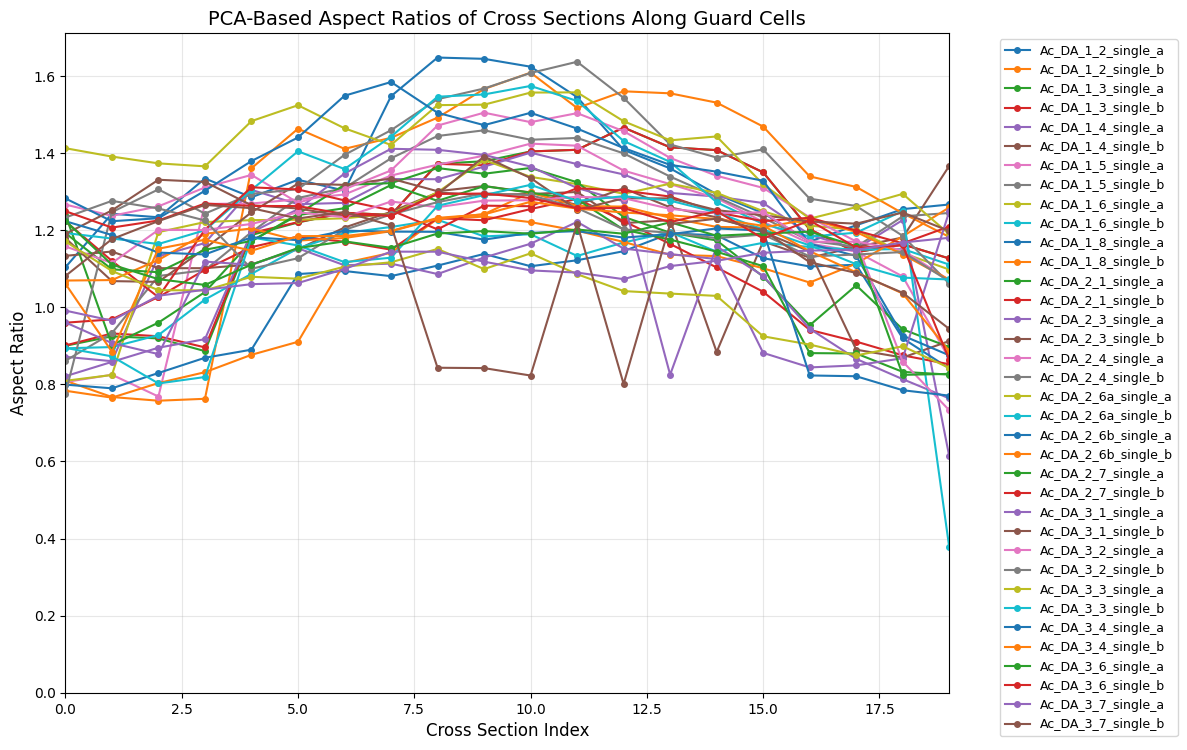

In [88]:
import matplotlib.pyplot as plt

from skimage.measure import EllipseModel
files = ["Ac_DA_1_2","Ac_DA_1_3","Ac_DA_1_4","Ac_DA_1_5","Ac_DA_1_6","Ac_DA_1_8","Ac_DA_2_1", "Ac_DA_2_3","Ac_DA_2_4","Ac_DA_2_6a","Ac_DA_2_6b", "Ac_DA_2_7","Ac_DA_3_1", "Ac_DA_3_2", "Ac_DA_3_3", "Ac_DA_3_4","Ac_DA_3_6", "Ac_DA_3_7"]
path = "Meshes/Onion meshes/"


# Create file list for labels
s = [f"{file}_{side}" for file in files for side in ["single_a", "single_b"]]

# Extract aspect ratios from all_data
aspect_ratios_list = [data['cross_sections']['aspect_ratios'] for data in all_data]

# Plot the PCA-based aspect ratios with better formatting
plt.figure(figsize=(12, 8))

for ar, file_name in zip(aspect_ratios_list, s):
    plt.plot(ar, '-o', linewidth=1.5, markersize=4, label=file_name)

plt.xlabel('Cross Section Index', fontsize=12)
plt.ylabel('Aspect Ratio', fontsize=12)
plt.title('PCA-Based Aspect Ratios of Cross Sections Along Guard Cells', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xlim(0, 19)  # Assuming 20 sections
plt.ylim(bottom=0)  # Start y-axis at 0

# Add legend in a separate box to the right
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()

# Save the figure
plt.savefig("pca_aspect_ratios.png", dpi=300, bbox_inches='tight')
plt.show()

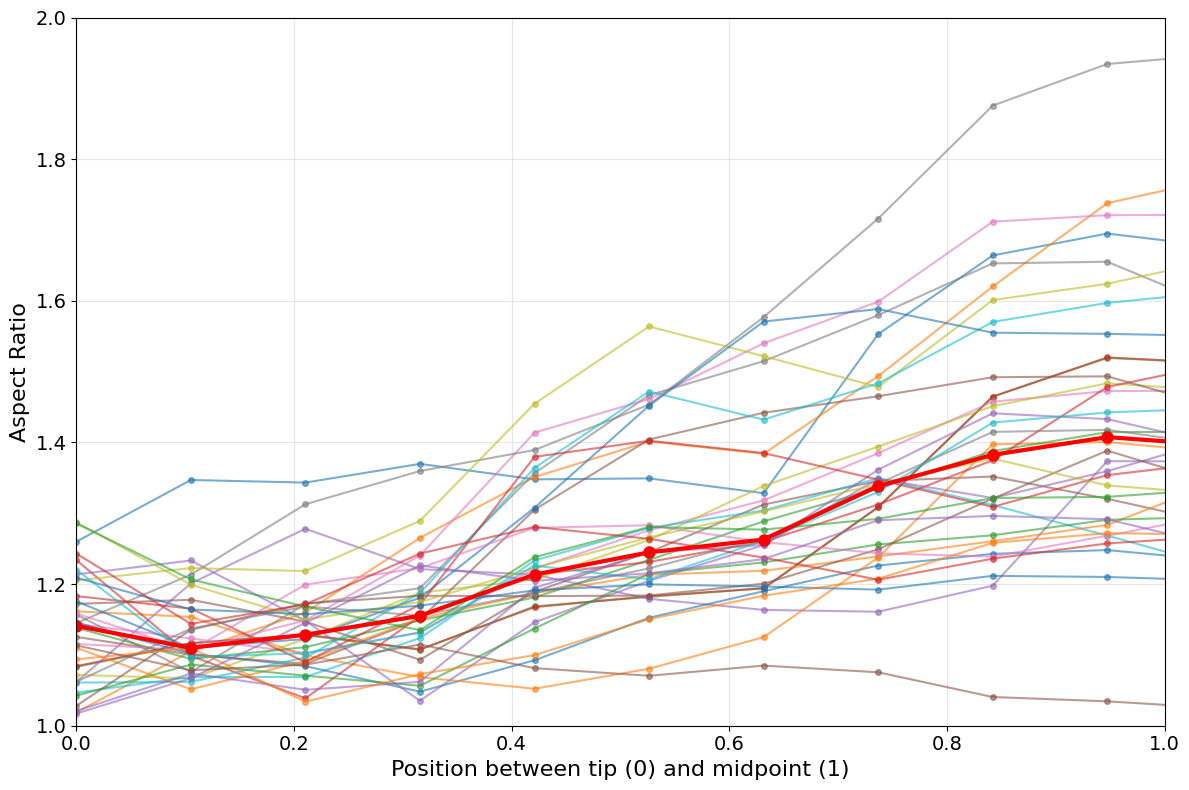

In [98]:
# Extract ellipse aspect ratios from all_data
ellipse_aspect_ratios_list = []
for data in all_data:
    ellipse_ars = []
    for ellipse_fit in data['cross_sections']['ellipse_fits']:
        if ellipse_fit is not None and 'aspect_ratio' in ellipse_fit:
            ellipse_ars.append(ellipse_fit['aspect_ratio'])
        else:
            ellipse_ars.append(np.nan)
    ellipse_aspect_ratios_list.append(ellipse_ars)


# Plot the ellipse-based aspect ratios with better formatting
plt.figure(figsize=(12, 8))

# Find the maximum length of all aspect ratio lists
max_length = max(len(ar) for ar in ellipse_aspect_ratios_list)

# Create padded array with NaN values for proper numpy handling
padded_aspect_ratios = []
for ar in ellipse_aspect_ratios_list:
    # Create array filled with NaN values
    padded_ar = np.full(max_length, np.nan)
    # Fill with actual values (as many as we have)
    padded_ar[:len(ar)] = ar
    padded_aspect_ratios.append(padded_ar)

# Convert to numpy array and calculate median at each index
all_aspect_ratios = np.array(padded_aspect_ratios)
median_aspect_ratios = np.nanmedian(all_aspect_ratios, axis=0)

## Create a xscale that goes from 0 to 2
xscale = np.linspace(0, 2, num=max_length)

# Plot individual cell aspect ratios with reduced opacity
for ar, file_name in zip(ellipse_aspect_ratios_list, s):
    plt.plot(xscale, ar, '-o', linewidth=1.5, markersize=4, alpha=0.6, label=file_name)

# Plot the median with a thicker, distinct line
plt.plot(xscale, median_aspect_ratios, 
         '-o', linewidth=3, markersize=8, color='red', 
         label='Median Aspect Ratio')

plt.xlabel('Position between tip (0) and midpoint (1)', fontsize=16)
plt.ylabel('Aspect Ratio', fontsize=16)
#plt.title('Ellipse-Based Aspect Ratios of Cross Sections Along Guard Cells', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)  
plt.ylim(1, 2)  # Start y-axis at 0
# Increase font size for tick labels
plt.tick_params(axis='both', which='major', labelsize=14)

# Add legend in a separate box to the right

plt.tight_layout()

# Save the figure
plt.savefig("ellipse_aspect_ratios_with_median.png", dpi=300, bbox_inches='tight')
plt.show()

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Extract the data for indices 0-9
x_range = x_indices[:10]  # First 10 indices (0-9)
y_range = median_aspect_ratios[:10]

# Define functions to fit
def linear(x, a, b):
    return a * x + b

def quadratic(x, a, b, c):
    return a * x**2 + b * x + c

def cubic(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d

def exponential(x, a, b, c):
    return a * np.exp(b * x) + c

# Fit each function
linear_params, _ = curve_fit(linear, x_range, y_range)
quadratic_params, _ = curve_fit(quadratic, x_range, y_range)
cubic_params, _ = curve_fit(cubic, x_range, y_range)
try:
    exponential_params, _ = curve_fit(exponential, x_range, y_range, p0=[1, 0.1, 1])
except:
    exponential_params = None

# Calculate R-squared for each fit
def calculate_r_squared(y_true, y_pred):
    ss_total = np.sum((y_true - np.mean(y_true))**2)
    ss_residual = np.sum((y_true - y_pred)**2)
    return 1 - (ss_residual / ss_total)

# Calculate R-squared values
linear_r2 = calculate_r_squared(y_range, linear(x_range, *linear_params))
quadratic_r2 = calculate_r_squared(y_range, quadratic(x_range, *quadratic_params))
cubic_r2 = calculate_r_squared(y_range, cubic(x_range, *cubic_params))
if exponential_params is not None:
    exponential_r2 = calculate_r_squared(y_range, exponential(x_range, *exponential_params))
else:
    exponential_r2 = 0

# Generate smooth curves for plotting
x_smooth = np.linspace(0, 9, 100)
linear_fit = linear(x_smooth, *linear_params)
quadratic_fit = quadratic(x_smooth, *quadratic_params)
cubic_fit = cubic(x_smooth, *cubic_params)
if exponential_params is not None:
    exponential_fit = exponential(x_smooth, *exponential_params)

# Plot the data and fits
plt.figure(figsize=(12, 8))
plt.scatter(x_range, y_range, color='black', s=80, label='Median Aspect Ratios')
plt.plot(x_smooth, linear_fit, label=f'Linear (R²={linear_r2:.3f})')
plt.plot(x_smooth, quadratic_fit, label=f'Quadratic (R²={quadratic_r2:.3f})')
plt.plot(x_smooth, cubic_fit, label=f'Cubic (R²={cubic_r2:.3f})')
if exponential_params is not None:
    plt.plot(x_smooth, exponential_fit, label=f'Exponential (R²={exponential_r2:.3f})')

plt.xlabel('Cross-Section Index', fontsize=14)
plt.ylabel('Median Aspect Ratio', fontsize=14)
plt.title('Fitted Functions to Median Aspect Ratios (Indices 0-9)', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("median_aspect_ratio_fit.png", dpi=300)
plt.show()

# Print the parameters for the best-fitting function
best_r2 = max(linear_r2, quadratic_r2, cubic_r2, exponential_r2)
if best_r2 == linear_r2:
    print(f"Best fit: Linear - y = {linear_params[0]:.4f}x + {linear_params[1]:.4f}")
elif best_r2 == quadratic_r2:
    print(f"Best fit: Quadratic - y = {quadratic_params[0]:.4f}x² + {quadratic_params[1]:.4f}x + {quadratic_params[2]:.4f}")
elif best_r2 == cubic_r2:
    print(f"Best fit: Cubic - y = {cubic_params[0]:.4f}x³ + {cubic_params[1]:.4f}x² + {cubic_params[2]:.4f}x + {cubic_params[3]:.4f}")
elif exponential_params is not None and best_r2 == exponential_r2:
    print(f"Best fit: Exponential - y = {exponential_params[0]:.4f}·e^({exponential_params[1]:.4f}·x) + {exponential_params[2]:.4f}")

NameError: name 'x_indices' is not defined

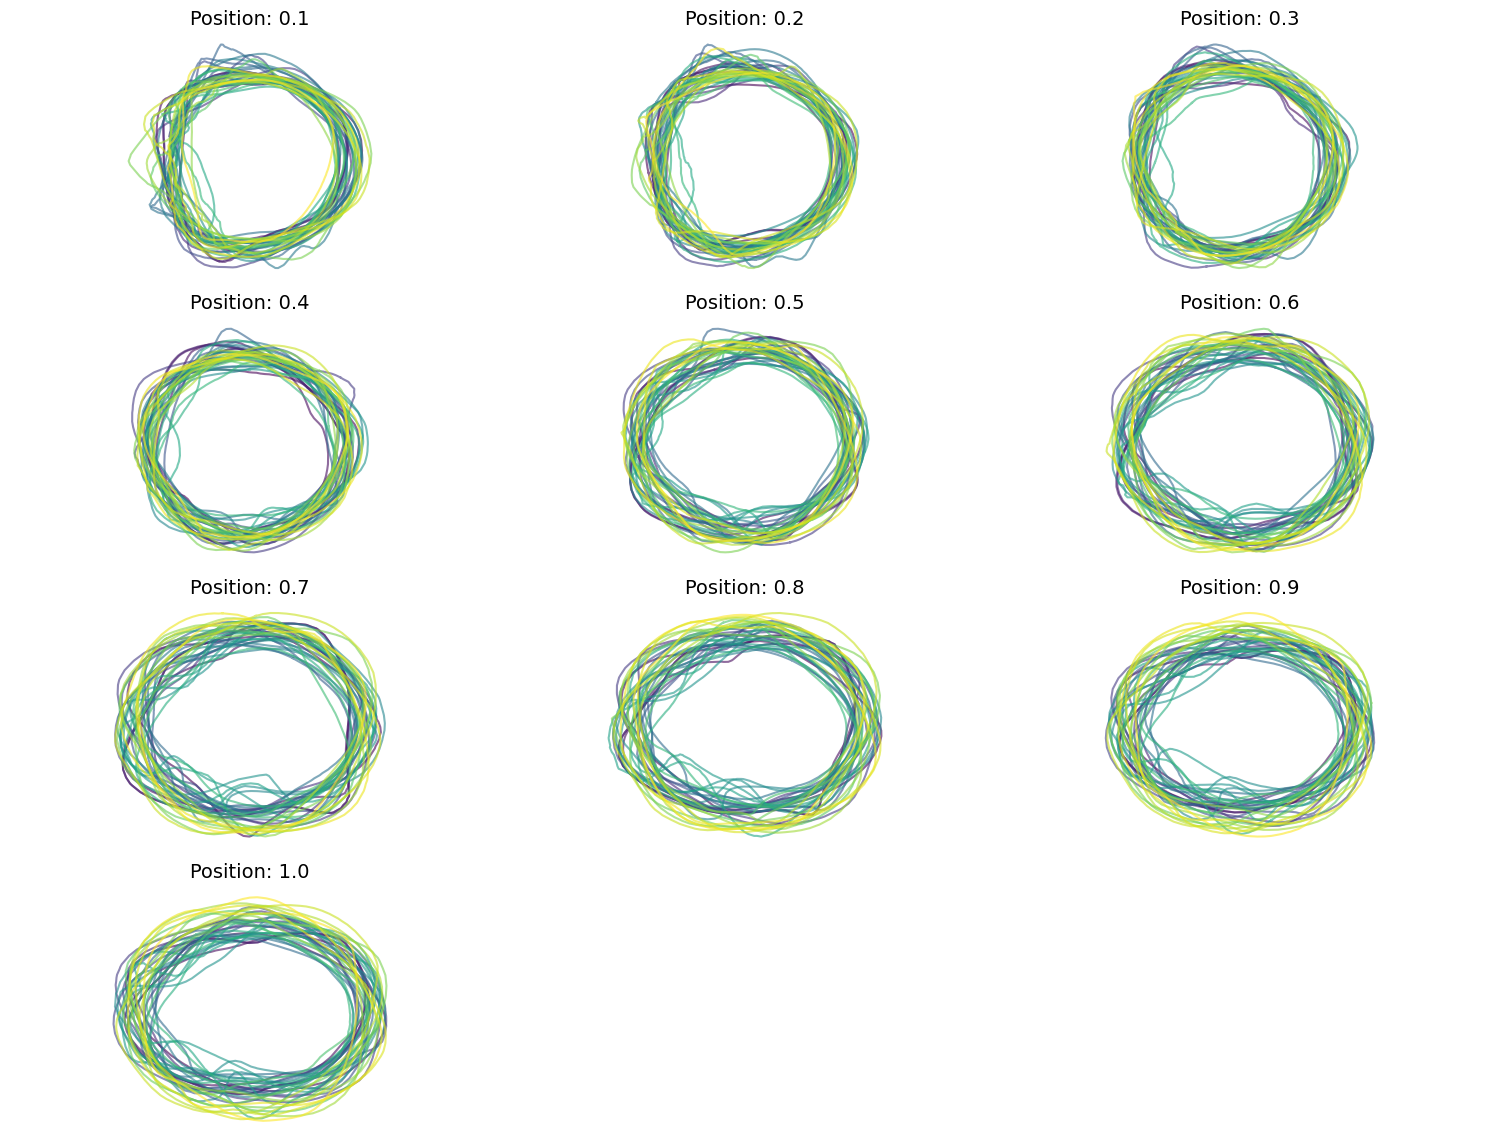

In [111]:
# Extract 2D cross-section points from all_data
all_sections_2d_points = []
for data in all_data:
    section_2d_points = []
    for section_points in data['cross_sections']['2d_points']:
        if section_points is not None:
            section_2d_points.append(np.array(section_points))
        else:
            section_2d_points.append(None)
    all_sections_2d_points.append(section_2d_points)

## Only plot first ten sections
n_sections_to_plot = 10

if all_sections_2d_points:
    n_meshes = len(all_sections_2d_points)
    n_sections = len(all_sections_2d_points[0]) if n_meshes > 0 else 0
    n_cols = 3
    n_rows = int(np.ceil(n_sections_to_plot / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows), squeeze=False)
    
    # Use a color cycle to distinguish meshes if needed, though it might get busy
    colors = plt.cm.viridis(np.linspace(0, 1, n_meshes))


    for plot_idx, section_idx in enumerate(range(n_sections_to_plot)):
        row, col = plot_idx // n_cols, plot_idx % n_cols
        ax = axes[row, col]
        
        for j in range(n_meshes):
            points_2d = all_sections_2d_points[j][section_idx]
            if points_2d is not None and len(points_2d) > 0:
                # Plot each shape with some transparency
                ax.plot(points_2d[:, 0], points_2d[:, 1], color=colors[j], alpha=0.6)

        ax.set_title(f'Position: {0.1 + section_idx * 0.1:.1f}', fontsize=14)
        ax.axis('equal')
        ax.axis('off')

    # Hide any unused subplots
    for k in range(n_sections_to_plot, n_rows * n_cols):
        row, col = k // n_cols, k % n_cols
        axes[row, col].axis('off')

    #plt.suptitle('Overlay of All Cross-Sections at Each Position', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig("cross_sections_overlay.png", dpi=300, bbox_inches='tight')
    plt.show()

In [113]:
def visualize_mesh_with_cross_sections(file_index=0, side="single_a", n_sections=20, colormap='viridis'):
    """
    Create a 3D visualization of a single mesh with all cross-sections.
    
    Parameters:
    -----------
    file_index : int
        Index of the file to visualize from the files list
    side : str
        Side to analyze ("single_a" or "single_b")
    n_sections : int
        Number of cross-sections to generate along the centreline
    colormap : str
        Matplotlib colormap name for coloring the cross-sections
    
    Returns:
    --------
    fig : plotly.graph_objects.Figure
        The 3D figure object that can be further customized if needed
    """
    import plotly.graph_objects as go
    import numpy as np
    import matplotlib.pyplot as plt
    
    # Select file
    file = files[file_index]
    
    # Load and process mesh
    mesh_path = f"{path}{file}/{file}_{side}.obj"
    mesh = trimesh.load(mesh_path, process=True)
    
    # Align the mesh to the Y-axis and center it
    mesh = align_mesh_to_y_axis(mesh)
    
    # Ensure consistent orientation
    outer_points_check = find_outer_edge(mesh, smoothing=50)
    if np.mean(outer_points_check[:, 0]) < 0:
        mesh.vertices[:, 0] *= -1
    
    # Process mesh to find centreline
    outer_points = find_outer_edge(mesh, smoothing=50)
    outer_curve_projected = create_projected_curve(
        mesh, outer_points, smooth=50, n_points=120, end_segment_size=10
    )

    # Get midpoint cross-section
    midpoint_trace, section_trace, section_points = get_midpoint_trace(outer_points, mesh)

    # Get the circle centers
    _, _, _, _, _, center_start, center_end = define_end_point_circles(outer_curve_projected, section_points)

    # Create the centreline using the actual circle centers
    section_midpoint = np.mean(section_points, axis=0)
    centreline, centreline_trace = create_bezier_centreline(
        center_start, section_midpoint, center_end, curve_points=50
    )

    # Define cross-section indices
    end_margin_points = 3  # Avoid unstable sections at the very ends
    start_index = end_margin_points
    end_index = len(centreline) - 1 - end_margin_points
    indices = np.linspace(start_index, end_index, n_sections, dtype=int)
    
    # Get all cross-sections
    all_section_points = get_cross_section_points(mesh, centreline, indices)
    
    # Calculate tangents along the centreline
    tangents = np.gradient(centreline, axis=0)
    tangents /= np.linalg.norm(tangents, axis=1, keepdims=True)
    
    # Create a colormap for cross-sections based on position
    color_scale = plt.cm.get_cmap(colormap)(np.linspace(0, 1, len(all_section_points)))
    
    # Create visualization traces
    traces = []
    
    # Add the mesh with transparency
    traces.append(go.Mesh3d(
        x=mesh.vertices[:, 0], y=mesh.vertices[:, 1], z=mesh.vertices[:, 2],
        i=mesh.faces[:, 0], j=mesh.faces[:, 1], k=mesh.faces[:, 2],
        color='lightgray', opacity=0.5, name='Mesh'
    ))
    
    # Add the centreline
    traces.append(go.Scatter3d(
        x=centreline[:, 0], y=centreline[:, 1], z=centreline[:, 2],
        mode='lines', line=dict(color='black', width=3), name='Centreline'
    ))
    
    # Process each cross-section
    for i, section_points in enumerate(all_section_points):
        if section_points is None or len(section_points) < 3:
            continue
            
        idx = indices[i]
        section_centroid = np.mean(section_points, axis=0)
        
        # Get RGB color for this cross-section
        color_rgb = color_scale[i][:3]  # Extract RGB (ignore alpha)
        color = f'rgb({int(color_rgb[0]*255)},{int(color_rgb[1]*255)},{int(color_rgb[2]*255)})'
        
        # Sort points for a clean polygon (circular order around centroid)
        tangent = tangents[idx]
        points_2d = section_points - section_centroid
        
        # Project onto plane perpendicular to tangent
        ref = np.array([0, 0, 1]) if not np.allclose(tangent, [0, 0, 1]) else np.array([1, 0, 0])
        v1 = np.cross(tangent, ref)
        v1 = v1 / np.linalg.norm(v1)
        v2 = np.cross(tangent, v1)
        v2 = v2 / np.linalg.norm(v2)
        
        x_2d = points_2d @ v1
        y_2d = points_2d @ v2
        
        # Sort by polar angle
        angles = np.arctan2(y_2d, x_2d)
        sorted_indices = np.argsort(angles)
        
        # Get sorted 3D points
        sorted_points = section_points[sorted_indices]
        
        # Close the loop by adding the first point at the end
        closed_points = np.vstack([sorted_points, sorted_points[0]])
        
        # Add the cross-section as a line trace
        traces.append(go.Scatter3d(
            x=closed_points[:, 0], y=closed_points[:, 1], z=closed_points[:, 2],
            mode='lines', line=dict(color=color, width=5),
            name=f'Section {i+1}'
        ))
    
    # Create the figure
    fig = go.Figure(data=traces)
    
    # Update layout
    fig.update_layout(
        title=f"Cross-Sections for {file}_{side}",
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z',
            aspectmode='data',
            camera=dict(
                eye=dict(x=1.5, y=0, z=0.5)  # Adjust for better viewing angle
            )
        )
    )
    
    # Save the visualization as an HTML file for interactive viewing
    output_filename = f"{file}_{side}_cross_sections_3d.html"
    fig.write_html(output_filename, include_plotlyjs='cdn')
    print(f"Saved 3D visualization to {output_filename}")
    
    # Show the figure
    fig.show()
    
    return fig

# Example usage:
visualize_mesh_with_cross_sections(file_index=0, side="single_a")

Saved 3D visualization to Ac_DA_1_2_single_a_cross_sections_3d.html


/var/folders/t5/q1tt12hd2sg29kw894zcfbtm000b_5/T/ipykernel_89442/1640637938.py:72: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



In [7]:
# Compute tangents along the centreline

def create_cross_sections(mesh, centreline, n_sections=10, end_margin_points=2):
    """
    Create cross sections tangential to the fitted centreline, avoiding the ends.
    
    Parameters:
    -----------
    mesh : trimesh.Trimesh
        The mesh to create cross sections on.
    centreline : ndarray
        The fitted centreline points (n_points, 3).
    n_sections : int
        The desired number of cross-sections.
    end_margin_points : int
        The number of points to exclude from each end of the centreline.
        
    Returns:
    --------
    traces : list
        List of Plotly traces for the cross sections and centreline.
    """
    
    # Compute tangents along the centreline
    tangents = np.gradient(centreline, axis=0)
    tangents = tangents / np.linalg.norm(tangents, axis=1, keepdims=True)

    import plotly.graph_objects as go

    mesh_trace = go.Mesh3d(
        x=mesh.vertices[:,0], y=mesh.vertices[:,1], z=mesh.vertices[:,2],
        i=mesh.faces[:,0], j=mesh.faces[:,1], k=mesh.faces[:,2],
        color='lightgray', opacity=0.5, name='Mesh'
    )

    traces = [mesh_trace]
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta', 'yellow', 'brown', 'pink']

    # Define the valid range for cross-sections, excluding the ends
    start_index = end_margin_points
    end_index = len(centreline) - 1 - end_margin_points

    # Ensure the range is valid and there are enough points
    if start_index >= end_index:
        print(f"Warning: Centreline is too short for the given margin of {end_margin_points} points. No cross-sections will be generated.")
        return traces

    # Select indices at regular intervals within the valid range
    indices = np.linspace(start_index, end_index, n_sections, dtype=int)

    # Create cross-sections only at selected indices
    for i, idx in enumerate(indices):
        pt = centreline[idx]
        tan = tangents[idx]
        section = mesh.section(plane_origin=pt, plane_normal=tan)
        if section is None:
            continue
        if hasattr(section, 'discrete'):
            segments = list(section.discrete)
            if segments:  # Check if segments list is not empty
                # Select the segment closest to the centreline point to avoid capturing the opposite side
                centroids = [seg.mean(axis=0) for seg in segments]
                dists = [np.linalg.norm(c - pt) for c in centroids]
                section_points = segments[int(np.argmin(dists))]
            else:
                continue  # Skip this section if no segments
        else:
            section_points = section.vertices
        
        if len(section_points) < 2:
            continue

        color = colors[i % len(colors)]
        traces.append(go.Scatter3d(
            x=section_points[:,0], y=section_points[:,1], z=section_points[:,2],
            mode='lines+markers',
            line=dict(color=color, width=5),
            marker=dict(size=3, color=color),
            name=f'CS {i+1}'
        ))

    return traces

In [10]:
def orient_2d_cross_section(section_points_3d, points_2d):
    """
    Orient 2D cross-section points consistently based on the 3D max X point.
    
    Parameters:
    -----------
    section_points_3d : ndarray
        Original 3D points of the cross-section
    points_2d : ndarray
        2D projection of the cross-section points
        
    Returns:
    --------
    oriented_points : ndarray
        Consistently oriented 2D points
    rotation_angle : float
        The angle used for rotation (for reference)
    """
    # Find the point with maximum X-coordinate in 3D space
    max_x_idx = np.argmax(section_points_3d[:, 0])
    
    # Get that same point in 2D projection
    max_x_2d = points_2d[max_x_idx]
    
    # Calculate the angle to rotate so max X point is at the right (0 degrees)
    max_vec = max_x_2d - np.zeros(2)  # Vector from origin to max X point
    current_angle = np.arctan2(max_vec[1], max_vec[0])
    target_angle = 0  # 0 degrees (right)
    rotation_angle = target_angle - current_angle
    
    # Create rotation matrix
    c, s = np.cos(rotation_angle), np.sin(rotation_angle)
    rotation_matrix = np.array([[c, -s], [s, c]])
    
    # Apply rotation to all points
    oriented_points = np.dot(points_2d, rotation_matrix.T)
    
    return oriented_points, rotation_angle

In [11]:
def fit_ellipse_and_determine_axes(section_points_3d, main_axis_vec, minor_axis_vec, pattern_reference, file_side=None, section_idx=None):
    """
    Fit an ellipse to oriented 2D points and determine its major/minor axes consistently.
    Major axis is always the one most aligned with horizontal X axis.
    """
    try:
        # Create 2D projection
        centered = section_points_3d - np.mean(section_points_3d, axis=0)
        x_coords = centered @ main_axis_vec
        y_coords = centered @ minor_axis_vec
        points_2d = np.column_stack([x_coords, y_coords])
        
        # Orient the 2D points consistently
        oriented_points_2d, _ = orient_2d_cross_section(section_points_3d, points_2d)
        
        ellipse_model = EllipseModel()
        # Try to fit an ellipse to the oriented 2D points
        if len(oriented_points_2d) >= 5 and ellipse_model.estimate(oriented_points_2d):
            # Get ellipse parameters: center (xc, yc), semi-axes lengths (a, b), angle
            params = ellipse_model.params
            xc, yc, a, b, theta = params
            
            # Create ellipse axes vectors in 2D
            # First axis (corresponding to 'a')
            axis1_vec_2d = np.array([np.cos(theta), np.sin(theta)])
            # Second axis (corresponding to 'b')
            axis2_vec_2d = np.array([-np.sin(theta), np.cos(theta)])
            
            # Determine which axis is more horizontal (aligned with [1,0] in 2D)
            x_axis_2d = np.array([1, 0])
            dot1_horiz = np.abs(np.dot(axis1_vec_2d, x_axis_2d))
            dot2_horiz = np.abs(np.dot(axis2_vec_2d, x_axis_2d))
            
            # Assign major/minor based on horizontal alignment
            if dot1_horiz >= dot2_horiz:
                # Axis 1 is more horizontally aligned, so it's the main axis
                main_axis_len, minor_axis_len = a, b
                is_axis1_main = True
            else:
                # Axis 2 is more horizontally aligned, so it's the main axis
                main_axis_len, minor_axis_len = b, a
                is_axis1_main = False
            
            # Calculate aspect ratio based on horizontal alignment
            if minor_axis_len > 1e-9:
                ellipse_ar = main_axis_len / minor_axis_len
            else:
                ellipse_ar = np.nan
                
            # Generate points along the ellipse for visualization
            t = np.linspace(0, 2*np.pi, 100)
            ellipse_x = xc + a * np.cos(t) * np.cos(theta) - b * np.sin(t) * np.sin(theta)
            ellipse_y = yc + a * np.cos(t) * np.sin(theta) + b * np.sin(t) * np.cos(theta)
            ellipse_points = np.column_stack([ellipse_x, ellipse_y])
            
            # Store the ellipse data with flag for which axis is main (horizontally-aligned)
            return (oriented_points_2d, ellipse_points, params, is_axis1_main), ellipse_ar
        else:
            return None, np.nan
    except Exception as e:
        if file_side and section_idx is not None:
            print(f"Ellipse fitting failed for {file_side} section {section_idx}: {e}")
        else:
            print(f"Ellipse fitting failed: {e}")
        return None, np.nan

In [12]:
def plot_cross_sections_with_metrics(all_sections_2d, all_ellipses, mesh_indices=None, 
                                    start_section=0, end_section=None, n_cols=4, figsize=(15, 10),
                                    mesh_names=None, save_metrics=True, output_prefix="cross_section_metrics"):
    """
    Plot cross-sections with their fitted ellipses, ensuring consistent axis orientation.
    Also calculates and optionally saves metrics including aspect ratios and areas.
    
    Parameters:
    -----------
    all_sections_2d : list
        List of 2D cross-section points for each mesh
    all_ellipses : list
        List of ellipse data for each mesh
    mesh_indices : list, optional
        Indices of meshes to visualize. If None, uses first mesh.
    start_section : int
        First section index to show
    end_section : int
        Last section index to show (exclusive). If None, shows all sections.
    n_cols : int
        Number of columns in the plot grid
    figsize : tuple
        Figure size
    mesh_names : list, optional
        List of names for each mesh. If None, uses index-based names.
    save_metrics : bool
        Whether to save metrics to CSV files
    output_prefix : str
        Prefix for output files
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    from matplotlib.path import Path
    
    # Reference vectors for consistent orientation
    global_reference_axis = np.array([1, 0, 0])  # For horizontal alignment fallback
    pattern_reference = np.array([1.0, 0.0, 1.0])  # Diagonal pattern in X-Z plane
    pattern_reference = pattern_reference / np.linalg.norm(pattern_reference)  # Normalize
    
    # Helper function to determine major/minor axes based on diagonal pattern
    def determine_ellipse_axes(axis1_vec_2d, axis2_vec_2d, a, b, theta):
        """Determine major/minor axes based on diagonal pattern alignment."""
        # Create 3D vectors from 2D ellipse axes (assuming XZ plane projection)
        # This is an approximation since we don't have the original 3D basis
        axis1_vec_3d = np.array([axis1_vec_2d[0], 0, axis1_vec_2d[1]])
        axis2_vec_3d = np.array([axis2_vec_2d[0], 0, axis2_vec_2d[1]])
        
        # Normalize for proper dot product comparison
        axis1_vec_3d = axis1_vec_3d / np.linalg.norm(axis1_vec_3d)
        axis2_vec_3d = axis2_vec_3d / np.linalg.norm(axis2_vec_3d)
        
        # The axis that's more horizontal (aligned with X) should be the major axis
        dot1_x = np.abs(axis1_vec_3d[0])  # X component of first axis
        dot2_x = np.abs(axis2_vec_3d[0])  # X component of second axis
        
        # The axis more aligned with X is the major axis
        if dot1_x >= dot2_x:
            # First axis is more aligned with X, so it's major
            major_len, major_cos, major_sin = a, np.cos(theta), np.sin(theta)
            minor_len, minor_cos, minor_sin = b, -np.sin(theta), np.cos(theta)
        else:
            # Second axis is more aligned with X, so it's major
            major_len, major_cos, major_sin = b, -np.sin(theta), np.cos(theta)
            minor_len, minor_cos, minor_sin = a, np.cos(theta), np.sin(theta)
                
        return major_len, minor_len, major_cos, major_sin, minor_cos, minor_sin
    
    # Default to first mesh if no indices provided
    if mesh_indices is None:
        mesh_indices = [0]
    
    for mesh_idx in mesh_indices:
        if mesh_idx >= len(all_sections_2d) or mesh_idx >= len(all_ellipses):
            print(f"Index {mesh_idx} is out of range")
            continue
            
        sections = all_sections_2d[mesh_idx]
        ellipses_data = all_ellipses[mesh_idx]
        
        # Get mesh name for labeling
        if mesh_names is not None and mesh_idx < len(mesh_names):
            mesh_name = mesh_names[mesh_idx]
        else:
            mesh_name = f"Mesh_{mesh_idx}"
        
        # Determine which sections to plot
        if end_section is None:
            end_section = len(sections)
        
        # Get valid section indices within the specified range
        valid_sections = []
        for i in range(start_section, min(end_section, len(sections))):
            if sections[i] is not None:  # We'll handle None ellipses separately
                valid_sections.append(i)
        
        if not valid_sections:
            print(f"No valid sections found for mesh {mesh_idx} in the specified range")
            continue
        
        # Create the grid of subplots
        n_plots = len(valid_sections)
        n_rows = int(np.ceil(n_plots / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, squeeze=False)
        
        # Storage for metrics
        metrics = {
            'section_idx': [],
            'aspect_ratio': [],
            'area_polygon': [],  # Area of the actual polygon
            'area_ellipse': [],  # Area of the fitted ellipse
            'major_axis_length': [],
            'minor_axis_length': []
        }
        
        # Plot each valid section with its ellipse
        for i, section_idx in enumerate(valid_sections):
            row, col = i // n_cols, i % n_cols
            ax = axes[row, col]
            
            # Get section points
            points = sections[section_idx]
            
            if points is not None and len(points) >= 3:
                # Calculate polygon area using Shoelace formula
                polygon_area = 0.0
                # Add first point at the end to close the loop if needed
                if not np.array_equal(points[0], points[-1]):
                    points_closed = np.vstack([points, points[0]])
                else:
                    points_closed = points
                
                # Calculate area using Shoelace formula
                x = points_closed[:, 0]
                y = points_closed[:, 1]
                polygon_area = 0.5 * np.abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))
                
                # Plot the cross-section points
                ax.scatter(points[:, 0], points[:, 1], s=15, c='blue', alpha=0.7, label='Points')
                
                # Get ellipse data
                ellipse_data = ellipses_data[section_idx] if section_idx < len(ellipses_data) else None
                
                # If we have valid ellipse data, plot it
                if ellipse_data is not None:
                    points_2d, ellipse_points, params, _ = ellipse_data
                    xc, yc, a, b, theta = params
                    
                    # Plot the ellipse
                    ax.plot(ellipse_points[:, 0], ellipse_points[:, 1], 'r-', lw=2, label='Fitted Ellipse')
                    
                    # First axis vector in 2D (corresponds to 'a')
                    axis1_vec_2d = np.array([np.cos(theta), np.sin(theta)])
                    # Second axis vector in 2D (corresponds to 'b')
                    axis2_vec_2d = np.array([-np.sin(theta), np.cos(theta)])
                    
                    # Use the pattern-based approach to determine major/minor axes
                    major_len, minor_len, major_cos, major_sin, minor_cos, minor_sin = determine_ellipse_axes(
                        axis1_vec_2d, axis2_vec_2d, a, b, theta
                    )
                    
                    # Calculate ellipse area
                    ellipse_area = np.pi * major_len * minor_len
                    
                    # Draw the major axis (pattern-aligned, green)
                    ax.plot([xc - major_len*major_cos, xc + major_len*major_cos],
                            [yc - major_len*major_sin, yc + major_len*major_sin], 
                            'g-', lw=1.5, label='Major axis' if i == 0 else None)
                    
                    # Draw the minor axis (perpendicular, blue)
                    ax.plot([xc - minor_len*minor_cos, xc + minor_len*minor_cos],
                            [yc - minor_len*minor_sin, yc + minor_len*minor_sin], 
                            'b-', lw=1.5, label='Minor axis' if i == 0 else None)
                    
                    # Calculate aspect ratio
                    aspect_ratio = major_len / minor_len
                    
                    # Store metrics
                    metrics['section_idx'].append(section_idx)
                    metrics['aspect_ratio'].append(aspect_ratio)
                    metrics['area_polygon'].append(polygon_area)
                    metrics['area_ellipse'].append(ellipse_area)
                    metrics['major_axis_length'].append(major_len)
                    metrics['minor_axis_length'].append(minor_len)
                    
                    # Add aspect ratio and area text
                    ax.text(0.05, 0.95, f"AR: {aspect_ratio:.2f}", transform=ax.transAxes,
                            va='top', ha='left', bbox=dict(facecolor='white', alpha=0.7))
                    ax.text(0.05, 0.85, f"Area: {ellipse_area:.2f}", transform=ax.transAxes,
                            va='top', ha='left', bbox=dict(facecolor='white', alpha=0.7))
                else:
                    # If no ellipse data, just store polygon info
                    metrics['section_idx'].append(section_idx)
                    metrics['aspect_ratio'].append(np.nan)
                    metrics['area_polygon'].append(polygon_area)
                    metrics['area_ellipse'].append(np.nan)
                    metrics['major_axis_length'].append(np.nan)
                    metrics['minor_axis_length'].append(np.nan)
            
            ax.set_title(f'Section {section_idx}')
            ax.set_aspect('equal')
            ax.grid(True, linestyle='--', alpha=0.5)
            
            # Add legend to the first plot only
            if i == 0:
                ax.legend(loc='lower right', fontsize=8)
        
        # Hide unused subplots
        for i in range(len(valid_sections), n_rows * n_cols):
            row, col = i // n_cols, i % n_cols
            axes[row, col].axis('off')
        
        # Save metrics to CSV if requested
        if save_metrics and metrics['section_idx']:
            df = pd.DataFrame(metrics)
            csv_filename = f"{output_prefix}_{mesh_name}.csv"
            df.to_csv(csv_filename, index=False)
            print(f"Saved metrics to {csv_filename}")
        
        # Add a title for the whole figure
        plt.suptitle(f'Cross-sections with Metrics - {mesh_name}', fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        
        # Save the figure
        plt.savefig(f"{output_prefix}_{mesh_name}_plot.png", dpi=300)
        plt.show()
        
        return metrics

In [ ]:
def fit_ellipse_with_pca_axes(points_2d):
    """Fit ellipse using PCA axes for consistent orientation."""
    # First calculate PCA to get consistent axes
    pca = PCA(n_components=2)
    pca.fit(points_2d)
    
    # Get consistently oriented axes
    x_axis = np.array([1, 0])
    comp0, comp1 = pca.components_
    
    # Determine which component is more horizontal
    if np.abs(np.dot(comp0, x_axis)) >= np.abs(np.dot(comp1, x_axis)):
        main_axis = comp0 if np.dot(comp0, x_axis) > 0 else -comp0
        minor_axis = comp1 if np.cross(main_axis, comp1) > 0 else -comp1
        main_std, minor_std = np.sqrt(pca.explained_variance_[0]), np.sqrt(pca.explained_variance_[1])
    else:
        main_axis = comp1 if np.dot(comp1, x_axis) > 0 else -comp1
        minor_axis = comp0 if np.cross(main_axis, comp0) > 0 else -comp0
        main_std, minor_std = np.sqrt(pca.explained_variance_[1]), np.sqrt(pca.explained_variance_[0])
    
    # Now fit ellipse
    ellipse_model = EllipseModel()
    if len(points_2d) >= 5 and ellipse_model.estimate(points_2d):
        xc, yc, a, b, theta = ellipse_model.params
        
        # Generate ellipse points for visualization
        t = np.linspace(0, 2*np.pi, 100)
        ellipse_x = xc + a * np.cos(t) * np.cos(theta) - b * np.sin(t) * np.sin(theta)
        ellipse_y = yc + a * np.cos(t) * np.sin(theta) + b * np.sin(t) * np.cos(theta)
        ellipse_points = np.column_stack([ellipse_x, ellipse_y])
        
        # Instead of using ellipse's native orientation, use PCA axes
        return {
            'points_2d': points_2d,
            'ellipse_points': ellipse_points,
            'params': ellipse_model.params,
            'pca_axes': {
                'main_axis': main_axis,
                'minor_axis': minor_axis,
                'main_std': main_std,
                'minor_std': minor_std
            }
        }
    else:
        return None

In [ ]:
def analyze_cross_section(section_points_3d, tangent):
    """Analyze a cross-section with consistent axis orientation using 2D PCA."""
    # 1. Project 3D points to 2D plane perpendicular to tangent
    section_centroid = np.mean(section_points_3d, axis=0)
    centered = section_points_3d - section_centroid
    
    # Create a consistent 2D basis
    ref = np.array([0, 0, 1]) if not np.allclose(tangent, [0, 0, 1]) else np.array([1, 0, 0])
    v1 = np.cross(tangent, ref)
    v1 /= np.linalg.norm(v1)
    v2 = np.cross(tangent, v1)
    v2 /= np.linalg.norm(v2)
    
    # Project the points to 2D
    x_2d = centered @ v1
    y_2d = centered @ v2
    points_2d = np.column_stack([x_2d, y_2d])
    
    # 2. Orient the 2D points consistently based on max X point
    max_x_idx = np.argmax(section_points_3d[:, 0])
    max_x_point = points_2d[max_x_idx]
    
    # Calculate angle to rotate so max X point is at 0 degrees
    max_vec = max_x_point - np.zeros(2)
    current_angle = np.arctan2(max_vec[1], max_vec[0])
    rotation_angle = 0 - current_angle
    
    # Create rotation matrix
    c, s = np.cos(rotation_angle), np.sin(rotation_angle)
    rotation_matrix = np.array([[c, -s], [s, c]])
    
    # Apply rotation
    points_2d = np.dot(points_2d, rotation_matrix.T)
    
    # 3. Perform PCA on the 2D points
    pca_2d = PCA(n_components=2)
    pca_2d.fit(points_2d)
    
    # 4. The first component is always the major axis in 2D
    # Ensure consistent orientation (major axis points right)
    component_0 = pca_2d.components_[0]
    if component_0[0] < 0:  # If pointing left, flip it
        component_0 = -component_0
    
    component_1 = pca_2d.components_[1]
    # Ensure second component points up for consistency
    if component_1[1] < 0:
        component_1 = -component_1
    
    # Get variances (axis lengths)
    std_devs = np.sqrt(pca_2d.explained_variance_)
    
    # Calculate aspect ratio
    aspect_ratio = std_devs[0] / std_devs[1] if std_devs[1] > 1e-9 else np.nan
    
    # 5. Fit ellipse to the 2D points with orientation consistent with PCA
    ellipse_data = None
    ellipse_ar = np.nan
    try:
        ellipse_model = EllipseModel()
        if len(points_2d) >= 5 and ellipse_model.estimate(points_2d):
            xc, yc, a, b, theta = ellipse_model.params
            
            # Create ellipse axes vectors in 2D
            axis1_vec = np.array([np.cos(theta), np.sin(theta)])  # First axis (a)
            axis2_vec = np.array([-np.sin(theta), np.cos(theta)]) # Second axis (b)
            
            # Check which ellipse axis is more aligned with the PCA main axis
            dot1 = np.abs(np.dot(axis1_vec, component_0))
            dot2 = np.abs(np.dot(axis2_vec, component_0))
            
            # Calculate aspect ratio consistently with PCA orientation
            if dot1 >= dot2:
                # First axis is more aligned with PCA main axis
                ellipse_ar = a / b if b > 1e-9 else np.nan
            else:
                # Second axis is more aligned with PCA main axis
                ellipse_ar = b / a if a > 1e-9 else np.nan
            
            # Generate ellipse points
            t = np.linspace(0, 2*np.pi, 100)
            ellipse_x = xc + a * np.cos(t) * np.cos(theta) - b * np.sin(t) * np.sin(theta)
            ellipse_y = yc + a * np.cos(t) * np.sin(theta) + b * np.sin(t) * np.cos(theta)
            ellipse_points = np.column_stack([ellipse_x, ellipse_y])
            
            ellipse_data = fit_ellipse_with_pca_axes(points_2d)
    except Exception as e:
        print(f"Ellipse fitting failed: {e}")
    
    return points_2d, component_0, component_1, std_devs, aspect_ratio, ellipse_data, ellipse_ar

In [ ]:
def process_all_files(files, path, pattern_reference):
    """
    Process all files to calculate aspect ratios and store cross-section data with consistent orientation.
    """
    # Initialize results storage
    results = {
        'aspect_ratios_list': [],
        'ellipse_aspect_ratios_list': [],
        'all_sections_2d_points': [],
        'all_ellipses': [],
        'mesh_names': []
    }
    
    for file in files:
        for side in ["single_a", "single_b"]:
            mesh_path = f"{path}{file}/{file}_{side}.obj"
            mesh = trimesh.load(mesh_path, process=True)
            
            # Align the mesh to the Y-axis and center it
            mesh = align_mesh_to_y_axis(mesh)
            
            # First, find the outer edge to determine orientation
            outer_points_check = find_outer_edge(mesh, smoothing=50)
            
            # If the cell's outer edge is on the negative x-side, flip the entire mesh
            if np.mean(outer_points_check[:, 0]) < 0:
                mesh.vertices[:, 0] *= -1
            
            # Now that all meshes are consistently oriented, proceed with analysis
            outer_points = find_outer_edge(mesh, smoothing=50)
            
            # Process the outer curve in one step
            outer_curve_projected = create_projected_curve(
                mesh, 
                outer_points,
                smooth=50,
                n_points=120,
                end_segment_size=10
            )
            
            # Create the centreline from the start and end circles
            section_midpoint = np.mean(outer_curve_projected, axis=0)
            centreline, centreline_trace = create_bezier_centreline(
                outer_curve_projected[0], section_midpoint, outer_curve_projected[-1], curve_points=50
            )
            
            # Define indices for cross-sections for the CURRENT centreline
            n_sections = 20
            end_margin_points = 3  # Avoids unstable sections at the very ends
            start_index = end_margin_points
            end_index = len(centreline) - 1 - end_margin_points
            indices = np.linspace(start_index, end_index, n_sections, dtype=int)
            all_section_points = get_cross_section_points(mesh, centreline, indices)

            # Pre-calculate tangents for all centreline points
            tangents = np.gradient(centreline, axis=0)
            tangents /= np.linalg.norm(tangents, axis=1, keepdims=True)
            
            aspect_ratios = []
            ellipse_aspect_ratios = []  # For ellipse-based aspect ratios
            current_mesh_sections_2d = []
            current_ellipses = []  # Store ellipse data for this mesh
            
            # Process each cross-section using our new 2D PCA approach
            for i, section_points in enumerate(all_section_points):
                # Skip if not enough points
                if section_points is None or len(section_points) < 5:
                    aspect_ratios.append(np.nan)
                    ellipse_aspect_ratios.append(np.nan)
                    current_mesh_sections_2d.append(None)
                    current_ellipses.append(None)
                    continue
                
                # Get the corresponding tangent for this section
                idx = indices[i]
                tangent = tangents[idx]
                
                # Use our new function to analyze the cross-section in 2D
                points_2d, major_axis, minor_axis, std_devs, ar, ellipse_data = analyze_cross_section(
                    section_points, tangent
                )
                
                # Store results
                aspect_ratios.append(ar)
                current_mesh_sections_2d.append(points_2d)
                
                # Handle ellipse data
                if ellipse_data is not None:
                    # Calculate ellipse-based aspect ratio
                    _, _, params = ellipse_data
                    _, _, a, b, _ = params
                    ellipse_ar = a / b if a > b else b / a
                    ellipse_aspect_ratios.append(ellipse_ar)
                    ellipse_data = fit_ellipse_with_pca_axes(points_2d)
                    current_ellipses.append(ellipse_data)
                else:
                    ellipse_aspect_ratios.append(np.nan)
                    current_ellipses.append(None)
            
            # Store the results for this mesh
            results['aspect_ratios_list'].append(aspect_ratios)
            results['ellipse_aspect_ratios_list'].append(ellipse_aspect_ratios)
            results['all_sections_2d_points'].append(current_mesh_sections_2d)
            results['all_ellipses'].append(current_ellipses)
            results['mesh_names'].append(f"{file}_{side}")
            
            # Print stats for both methods
            print(f"Processed {file}_{side}:")
            print(f"  PCA AR:     Mean = {np.nanmean(aspect_ratios):.3f}, Median = {np.nanmedian(aspect_ratios):.3f}")
            print(f"  Ellipse AR: Mean = {np.nanmean(ellipse_aspect_ratios):.3f}, Median = {np.nanmedian(ellipse_aspect_ratios):.3f}")
    
    return results

In [ ]:
# Define files and path
from skimage.measure import EllipseModel
files = ["Ac_DA_1_2","Ac_DA_1_3","Ac_DA_1_4","Ac_DA_1_5","Ac_DA_1_6","Ac_DA_1_8","Ac_DA_2_1", "Ac_DA_2_3","Ac_DA_2_4","Ac_DA_2_6a","Ac_DA_2_6b", "Ac_DA_2_7","Ac_DA_3_1", "Ac_DA_3_2", "Ac_DA_3_3", "Ac_DA_3_4","Ac_DA_3_6", "Ac_DA_3_7"]
path = "Meshes/Onion meshes/"

# Define pattern reference once
pattern_reference = np.array([1.0, 0.0, 1.0])  # Diagonal pattern in X-Z plane
pattern_reference = pattern_reference / np.linalg.norm(pattern_reference)  # Normalize

# Process all files and store results
results = process_all_files(files, path, pattern_reference)

# Extract data for visualization
aspect_ratios_list = results['aspect_ratios_list']
ellipse_aspect_ratios_list = results['ellipse_aspect_ratios_list']
all_sections_2d_points = results['all_sections_2d_points']
all_ellipses = results['all_ellipses']
mesh_names = results['mesh_names']

# Create file names list for plotting
s = mesh_names

# Example: Visualize results for a single mesh
metrics = plot_cross_sections_with_metrics(
    all_sections_2d_points, 
    all_ellipses,
    mesh_indices=[0],  # Visualize first mesh, customize as needed
    mesh_names=mesh_names,
    save_metrics=True,
    output_prefix="results/cross_section"
)

In [ ]:
## Create our file list
s = [f"{file}_{side}" for file in files for side in ["single_a", "single_b"]]

# Plot the aspect ratios for each mesh
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
for ar, file_name in zip(aspect_ratios_list, s):
    plt.plot(ar, label=file_name)  # Use individual file name as label
plt.xlabel('Cross Section Index')
plt.ylabel('Aspect Ratio')
plt.title('Aspect Ratios of Cross Sections Along Guard Cells')
plt.grid()

# Plot the ellipse-based aspect ratios
plt.figure(figsize=(10, 6))
for ar, file_name in zip(ellipse_aspect_ratios_list, s):
    plt.plot(ar, label=file_name)  # Use individual file name as label
plt.xlabel('Cross Section Index')
plt.ylabel('Aspect Ratio')
plt.title('Ellipse-Based Aspect Ratios of Cross Sections Along Guard Cells')
plt.xlim(0, 19)  # Assuming 20 sections
plt.grid()

In [ ]:
def visualize_cross_sections_in_mesh(file_index=0, n_sections=20, save_html=True):
    """
    Visualize cross-sections directly embedded in the 3D mesh and also display 2D
    cross-sections with aspect ratio measurements using the new 2D PCA method.
    """
    # Select file
    file = files[file_index]
    side = "single_a"  # You can change this to "single_b" if needed
    
    mesh_path = f"{path}{file}/{file}_{side}.obj"
    mesh = trimesh.load(mesh_path, process=True)
    
    # Align the mesh to the Y-axis and center it
    mesh = align_mesh_to_y_axis(mesh)
    
    # Ensure consistent orientation
    outer_points_check = find_outer_edge(mesh, smoothing=50)
    if np.mean(outer_points_check[:, 0]) < 0:
        mesh.vertices[:, 0] *= -1
    
    # Process mesh to find centreline
    outer_points = find_outer_edge(mesh, smoothing=50)
    outer_curve_projected = create_projected_curve(
        mesh, outer_points, smooth=50, n_points=120, end_segment_size=10
    )

    # First get midpoint cross-section
    midpoint_trace, section_trace, section_points = get_midpoint_trace(outer_points, mesh)

    # Then get the circle centers
    circle_start_trace, circle_end_trace, outer_projected_trace, center_start_trace, center_end_trace, center_start, center_end = define_end_point_circles(outer_curve_projected, section_points)

    # Now create the centreline using the actual circle centers
    section_midpoint = np.mean(section_points, axis=0)  # Use actual cross-section midpoint
    centreline, centreline_trace = create_bezier_centreline(
        center_start, section_midpoint, center_end, curve_points=50
    )

    # Define cross-section indices
    end_margin_points = 3  # Avoid unstable sections at the very ends
    start_index = end_margin_points
    end_index = len(centreline) - 1 - end_margin_points
    indices = np.linspace(start_index, end_index, n_sections, dtype=int)
    
    # Get all cross-sections
    all_section_points = get_cross_section_points(mesh, centreline, indices)
    
    # Calculate tangents along the centreline
    tangents = np.gradient(centreline, axis=0)
    tangents /= np.linalg.norm(tangents, axis=1, keepdims=True)
    
    # --- 3D Visualization ---
    traces = []

    # Add the mesh with transparency
    traces.append(go.Mesh3d(
        x=mesh.vertices[:, 0], y=mesh.vertices[:, 1], z=mesh.vertices[:, 2],
        i=mesh.faces[:, 0], j=mesh.faces[:, 1], k=mesh.faces[:, 2],
        color='lightgray', opacity=0.5, name='Mesh'
    ))

    # Add the centreline
    traces.append(go.Scatter3d(
        x=centreline[:, 0], y=centreline[:, 1], z=centreline[:, 2],
        mode='lines', line=dict(color='black', width=3), name='Centreline'
    ))
    
    # Add the circle traces
    traces.append(circle_start_trace)
    traces.append(circle_end_trace)
    traces.append(center_start_trace)
    traces.append(center_end_trace)
    
    # Create a colormap for cross-sections based on position
    colormap = plt.cm.viridis(np.linspace(0, 1, len(all_section_points)))

    # Store 2D analysis results
    aspect_ratios = []
    all_2d_points = []
    all_ellipses = []

    # Process each cross-section
    for i, section_points in enumerate(all_section_points):
        if section_points is None or len(section_points) < 5:
            aspect_ratios.append(np.nan)
            all_2d_points.append(None)
            all_ellipses.append(None)
            continue
            
        idx = indices[i]
        tangent = tangents[idx]
        
        # Use our new function to analyze the cross-section in 2D
        points_2d, major_axis, minor_axis, std_devs, ar, ellipse_data = analyze_cross_section(
            section_points, tangent
        )
        
        # Store results
        aspect_ratios.append(ar)
        all_2d_points.append(points_2d)
        all_ellipses.append(ellipse_data)
        
        # Add the 3D cross-section to the visualization
        section_centroid = np.mean(section_points, axis=0)
        
        # Get RGB color for this cross-section
        color_rgb = colormap[i][:3]  # Extract RGB (ignore alpha)
        color = f'rgb({int(color_rgb[0]*255)},{int(color_rgb[1]*255)},{int(color_rgb[2]*255)})'
        
        # Create a closed polygon from the cross-section points
        hull = ConvexHull(section_points)
        hull_vertices = section_points[hull.vertices]
        hull_vertices = np.vstack([hull_vertices, hull_vertices[0]])  # Close the loop
        
        # Add the cross-section as a line trace
        traces.append(go.Scatter3d(
            x=hull_vertices[:, 0], y=hull_vertices[:, 1], z=hull_vertices[:, 2],
            mode='lines', line=dict(color=color, width=5),
            name=f'Cross-section {i+1}'
        ))

    # Create the 3D figure
    fig3d = go.Figure(data=traces)
    
    # Update layout
    fig3d.update_layout(
        title=f"Cross-Sections in Mesh: {file}_{side}",
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z',
            aspectmode='data',
            camera=dict(
                eye=dict(x=1.5, y=0, z=0.5)  # Adjust for better viewing angle
            )
        ),
        legend=dict(
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=0.01
        )
    )
    
    # Save to HTML if requested
    if save_html:
        output_filename = f"{file}_{side}_cross_sections_in_mesh.html"
        fig3d.write_html(output_filename, include_plotlyjs='cdn')
        print(f"Saved 3D visualization to {output_filename}")
    
    # --- 2D Visualization with Aspect Ratios ---
    # Create a grid plot for the 2D cross-sections
    n_cols = min(5, n_sections)
    n_rows = int(np.ceil(n_sections / n_cols))
    fig2d, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows), squeeze=False)
    
    # Process each cross-section for 2D visualization
    for i in range(len(all_2d_points)):
        if all_2d_points[i] is None:
            continue
            
        row, col = i // n_cols, i % n_cols
        ax = axes[row, col]
        
        # Get the 2D points and ellipse data
        points_2d = all_2d_points[i]
        ellipse_data = all_ellipses[i]
        
        # Plot the 2D points
        ax.scatter(points_2d[:, 0], points_2d[:, 1], c='blue', s=20, alpha=0.7)
        
        # Plot ellipse if available
        if ellipse_data is not None:
            _, ellipse_points, params = ellipse_data
            xc, yc, a, b, theta = params
            
            # Plot the ellipse
            ax.plot(ellipse_points[:, 0], ellipse_points[:, 1], 'r-', lw=2)
            
            # Draw the axes
            cos_theta, sin_theta = np.cos(theta), np.sin(theta)
            
            # First axis (a)
            ax.plot([xc - a*cos_theta, xc + a*cos_theta],
                    [yc - a*sin_theta, yc + a*sin_theta], 
                    'g-', lw=1.5)
            
            # Second axis (b)
            ax.plot([xc + b*sin_theta, xc - b*sin_theta],
                    [yc - b*cos_theta, yc + b*cos_theta], 
                    'b-', lw=1.5)
            
            # Add aspect ratio text
            ax.text(0.05, 0.95, f"AR: {aspect_ratios[i]:.2f}", transform=ax.transAxes,
                    va='top', ha='left', bbox=dict(facecolor='white', alpha=0.7))
        
        ax.set_title(f'Section {i+1}')
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for i in range(len(all_2d_points), n_rows * n_cols):
        row, col = i // n_cols, i % n_cols
        axes[row, col].axis('off')
    
    # Add a title for the 2D visualization
    plt.suptitle(f'Cross-sections with Aspect Ratios - {file}_{side}', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    # Save the 2D figure
    plt.savefig(f"{file}_{side}_cross_sections_2d.png", dpi=300)
    print(f"Saved 2D visualization to {file}_{side}_cross_sections_2d.png")
    
    # Plot aspect ratios along the length of the cell
    plt.figure(figsize=(10, 5))
    plt.plot(range(len(aspect_ratios)), aspect_ratios, 'o-')
    plt.xlabel('Section Index')
    plt.ylabel('Aspect Ratio')
    plt.title(f'Aspect Ratios Along Cell - {file}_{side}')
    plt.grid(True)
    plt.savefig(f"{file}_{side}_aspect_ratios.png", dpi=300)
    print(f"Saved aspect ratio plot to {file}_{side}_aspect_ratios.png")
    
    # Show the 3D figure
    fig3d.show()
    
    return fig3d, aspect_ratios

In [ ]:
def visualize_cross_sections_in_mesh(file_index=0, n_sections=20, save_html=True):
    """
    Visualize cross-sections directly embedded in the 3D mesh and also display 2D
    cross-sections with aspect ratio measurements.
    
    Parameters:
    -----------
    file_index : int
        Index of the file to visualize from the files list
    n_sections : int
        Number of cross-sections to generate along the centreline
    save_html : bool
        Whether to save the visualization as an HTML file
    """
    import matplotlib.pyplot as plt
    from sklearn.decomposition import PCA
    from skimage.measure import EllipseModel
    
    # Select file
    file = files[file_index]
    side = "single_a"  # You can change this to "single_b" if needed
    
    mesh_path = f"{path}{file}/{file}_{side}.obj"
    mesh = trimesh.load(mesh_path, process=True)
    
    # Align the mesh to the Y-axis and center it
    mesh = align_mesh_to_y_axis(mesh)
    
    # Ensure consistent orientation
    outer_points_check = find_outer_edge(mesh, smoothing=50)
    if np.mean(outer_points_check[:, 0]) < 0:
        mesh.vertices[:, 0] *= -1
    
    # Process mesh to find centreline
    outer_points = find_outer_edge(mesh, smoothing=50)
    outer_curve_projected = create_projected_curve(
        mesh, outer_points, smooth=50, n_points=120, end_segment_size=10
    )

    # First get midpoint cross-section
    midpoint_trace, section_trace, section_points = get_midpoint_trace(outer_points, mesh)

    # Then get the circle centers
    circle_start_trace, circle_end_trace, outer_projected_trace, center_start_trace, center_end_trace, center_start, center_end = define_end_point_circles(outer_curve_projected, section_points)

    # Now create the centreline using the actual circle centers
    section_midpoint = np.mean(section_points, axis=0)  # Use actual cross-section midpoint
    centreline, centreline_trace = create_bezier_centreline(
        center_start, section_midpoint, center_end, curve_points=50
    )

    # Define cross-section indices
    end_margin_points = 3  # Avoid unstable sections at the very ends
    start_index = end_margin_points
    end_index = len(centreline) - 1 - end_margin_points
    indices = np.linspace(start_index, end_index, n_sections, dtype=int)
    
    # Get all cross-sections
    all_section_points = get_cross_section_points(mesh, centreline, indices)
    
    # Calculate tangents along the centreline
    tangents = np.gradient(centreline, axis=0)
    tangents /= np.linalg.norm(tangents, axis=1, keepdims=True)
    
    # --- 3D Visualization ---
    traces = []

    # Add the mesh with transparency
    traces.append(go.Mesh3d(
        x=mesh.vertices[:, 0], y=mesh.vertices[:, 1], z=mesh.vertices[:, 2],
        i=mesh.faces[:, 0], j=mesh.faces[:, 1], k=mesh.faces[:, 2],
        color='lightgray', opacity=0.5, name='Mesh'
    ))

    # Add the centreline
    traces.append(go.Scatter3d(
        x=centreline[:, 0], y=centreline[:, 1], z=centreline[:, 2],
        mode='lines', line=dict(color='black', width=3), name='Centreline'
    ))
    
    # Add the circle traces
    traces.append(circle_start_trace)
    traces.append(circle_end_trace)
    traces.append(center_start_trace)
    traces.append(center_end_trace)
    
    # Create a colormap for cross-sections based on position
    colormap = plt.cm.viridis(np.linspace(0, 1, len(all_section_points)))

    # Process each cross-section for 3D visualization
    for i, section_points in enumerate(all_section_points):
        if section_points is None or len(section_points) < 3:
            continue
            
        idx = indices[i]
        section_centroid = np.mean(section_points, axis=0)
        
        # Get RGB color for this cross-section
        color_rgb = colormap[i][:3]  # Extract RGB (ignore alpha)
        color = f'rgb({int(color_rgb[0]*255)},{int(color_rgb[1]*255)},{int(color_rgb[2]*255)})'
        
        # Sort points for a clean polygon (circular order around centroid)
        tangent = tangents[idx]
        points_2d = section_points - section_centroid
        
        # Project onto plane perpendicular to tangent
        ref = np.array([0, 0, 1]) if not np.allclose(tangent, [0, 0, 1]) else np.array([1, 0, 0])
        v1 = np.cross(tangent, ref)
        v1 = v1 / np.linalg.norm(v1)
        v2 = np.cross(tangent, v1)
        v2 = v2 / np.linalg.norm(v2)
        
        x_2d = points_2d @ v1
        y_2d = points_2d @ v2
        
        # Sort by polar angle
        angles = np.arctan2(y_2d, x_2d)
        sorted_indices = np.argsort(angles)
        
        # Get sorted 3D points
        sorted_points = section_points[sorted_indices]
        
        # Close the loop by adding the first point at the end
        closed_points = np.vstack([sorted_points, sorted_points[0]])
        
        # Add the cross-section as a line trace
        traces.append(go.Scatter3d(
            x=closed_points[:, 0], y=closed_points[:, 1], z=closed_points[:, 2],
            mode='lines', line=dict(color=color, width=5),
            name=f'Cross-section {i+1}'
        ))

    # Create the 3D figure
    fig3d = go.Figure(data=traces)
    
    # Update layout
    fig3d.update_layout(
        title=f"Cross-Sections in Mesh: {file}_{side}",
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z',
            aspectmode='data',
            camera=dict(
                eye=dict(x=1.5, y=0, z=0.5)  # Adjust for better viewing angle
            )
        ),
        legend=dict(
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=0.01
        )
    )
    
    # Save to HTML if requested
    if save_html:
        output_filename = f"{file}_{side}_cross_sections_in_mesh.html"
        fig3d.write_html(output_filename, include_plotlyjs='cdn')
        print(f"Saved 3D visualization to {output_filename}")
    
    # --- 2D Visualization with Aspect Ratios ---
    # Define a consistent reference for orientation
    pattern_reference = np.array([1.0, 0.0, 1.0])  # Diagonal pattern in X-Z plane
    pattern_reference = pattern_reference / np.linalg.norm(pattern_reference)  # Normalize
    
    # Create a grid plot for the 2D cross-sections
    n_cols = min(5, n_sections)
    n_rows = int(np.ceil(n_sections / n_cols))
    fig2d, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows), squeeze=False)
    
    # Process each cross-section for 2D visualization
    aspect_ratios = []
    for i, section_points in enumerate(all_section_points):
        if section_points is None or len(section_points) < 3:
            aspect_ratios.append(np.nan)
            continue
            
        idx = indices[i]
        row, col = i // n_cols, i % n_cols
        ax = axes[row, col]
        
        # Perform PCA
        pca = PCA(n_components=2)
        pca.fit(section_points)
        std_devs = np.sqrt(pca.explained_variance_)

        # Get PCA components
        component_0 = pca.components_[0]
        component_1 = pca.components_[1]

        # CONSISTENT HORIZONTAL ALIGNMENT:
        # Check which component is more aligned with X-axis
        x_axis = np.array([1, 0, 0])
        dot_0_x = np.abs(np.dot(component_0, x_axis))
        dot_1_x = np.abs(np.dot(component_1, x_axis))

        # The component more aligned with X is the major axis
        if dot_0_x >= dot_1_x:
            main_axis_vec = component_0 if np.dot(component_0, x_axis) >= 0 else -component_0
            minor_axis_vec = component_1 if np.cross(main_axis_vec, component_1)[1] >= 0 else -component_1
            main_axis_std, minor_axis_std = std_devs[0], std_devs[1]
        else:
            main_axis_vec = component_1 if np.dot(component_1, x_axis) >= 0 else -component_1
            minor_axis_vec = component_0 if np.cross(main_axis_vec, component_0)[1] >= 0 else -component_0
            main_axis_std, minor_axis_std = std_devs[1], std_devs[0]
        
        # Calculate aspect ratio
        if minor_axis_std > 1e-9:
            aspect_ratio = main_axis_std / minor_axis_std
            aspect_ratios.append(aspect_ratio)
        else:
            aspect_ratio = np.nan
            aspect_ratios.append(np.nan)
        
        # Project points to 2D using the principal axes
        centroid = np.mean(section_points, axis=0)
        centered = section_points - centroid
        x_coords = centered @ main_axis_vec
        y_coords = centered @ minor_axis_vec
        points_2d = np.column_stack([x_coords, y_coords])
        
        # Plot the 2D points
        ax.scatter(points_2d[:, 0], points_2d[:, 1], c='blue', s=20, alpha=0.7)
        
        # Fit an ellipse to the 2D points
        try:
            ellipse_model = EllipseModel()
            if len(points_2d) >= 5 and ellipse_model.estimate(points_2d):
                xc, yc, a, b, theta = ellipse_model.params
                
                # Generate points along the ellipse
                t = np.linspace(0, 2*np.pi, 100)
                ellipse_x = xc + a * np.cos(t) * np.cos(theta) - b * np.sin(t) * np.sin(theta)
                ellipse_y = yc + a * np.cos(t) * np.sin(theta) + b * np.sin(t) * np.cos(theta)
                
                # Plot the ellipse
                ax.plot(ellipse_x, ellipse_y, 'r-', lw=2)
                
                # Draw the major and minor axes
                cos_theta, sin_theta = np.cos(theta), np.sin(theta)
                
                # Calculate ellipse aspect ratio
                ellipse_ar = max(a, b) / min(a, b)
                
                # Draw the axes
                ax.plot([xc - a*cos_theta, xc + a*cos_theta],
                        [yc - a*sin_theta, yc + a*sin_theta], 
                        'g-', lw=1.5)
                
                ax.plot([xc + b*sin_theta, xc - b*sin_theta],
                        [yc - b*cos_theta, yc + b*cos_theta], 
                        'b-', lw=1.5)
                
                # Add aspect ratio text
                ax.text(0.05, 0.95, f"AR: {ellipse_ar:.2f}", transform=ax.transAxes,
                        va='top', ha='left', bbox=dict(facecolor='white', alpha=0.7))
            else:
                # No ellipse fit, use PCA aspect ratio
                ax.text(0.05, 0.95, f"AR: {aspect_ratio:.2f}", transform=ax.transAxes,
                        va='top', ha='left', bbox=dict(facecolor='white', alpha=0.7))
        except Exception as e:
            # Fallback to PCA aspect ratio if ellipse fitting fails
            print(f"Ellipse fitting failed for section {i}: {str(e)}")
            ax.text(0.05, 0.95, f"AR: {aspect_ratio:.2f}", transform=ax.transAxes,
                    va='top', ha='left', bbox=dict(facecolor='white', alpha=0.7))
        
        ax.set_title(f'Section {i+1}')
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for i in range(len(all_section_points), n_rows * n_cols):
        row, col = i // n_cols, i % n_cols
        axes[row, col].axis('off')
    
    # Add a title for the 2D visualization
    plt.suptitle(f'Cross-sections with Aspect Ratios - {file}_{side}', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    # Save the 2D figure
    plt.savefig(f"{file}_{side}_cross_sections_2d.png", dpi=300)
    print(f"Saved 2D visualization to {file}_{side}_cross_sections_2d.png")
    
    # Plot aspect ratios along the length of the cell
    plt.figure(figsize=(10, 5))
    plt.plot(range(len(aspect_ratios)), aspect_ratios, 'o-')
    plt.xlabel('Section Index')
    plt.ylabel('Aspect Ratio')
    plt.title(f'Aspect Ratios Along Cell - {file}_{side}')
    plt.grid(True)
    plt.savefig(f"{file}_{side}_aspect_ratios.png", dpi=300)
    print(f"Saved aspect ratio plot to {file}_{side}_aspect_ratios.png")
    
    # Show the 3D figure
    fig3d.show()
    
    return fig3d, aspect_ratios

In [ ]:
# Define files and path
from skimage.measure import EllipseModel
files = ["Ac_DA_1_2","Ac_DA_1_3","Ac_DA_1_4","Ac_DA_1_5","Ac_DA_1_6","Ac_DA_1_8","Ac_DA_2_1", "Ac_DA_2_3","Ac_DA_2_4","Ac_DA_2_6a","Ac_DA_2_6b", "Ac_DA_2_7","Ac_DA_3_1", "Ac_DA_3_2", "Ac_DA_3_3", "Ac_DA_3_4","Ac_DA_3_6", "Ac_DA_3_7"]
path = "Meshes/Onion meshes/"

# Define pattern reference once
pattern_reference = np.array([1.0, 0.0, 1.0])  # Diagonal pattern in X-Z plane
pattern_reference = pattern_reference / np.linalg.norm(pattern_reference)  # Normalize

# Process all files and store results
results = process_all_files(files, path, pattern_reference)

# Extract data for visualization
aspect_ratios_list = results['aspect_ratios_list']
ellipse_aspect_ratios_list = results['ellipse_aspect_ratios_list']
all_sections_2d_points = results['all_sections_2d_points']
all_ellipses = results['all_ellipses']
mesh_names = results['mesh_names']

# Visualize the first mesh in the list
aspect_ratios_list = []

for i in range(len(files)):
    # Unpack both return values - the figure and the aspect ratios
    fig3d, aspect_ratios = visualize_cross_sections_in_mesh(file_index=i)
    aspect_ratios_list.append(aspect_ratios)

In [ ]:
##Plot the aspect ratios for each mesh
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
for ar, file_name in zip(aspect_ratios_list, files):
    plt.plot(ar, label=file_name)  # Use individual file name as label
plt.xlabel('Cross Section Index')
plt.ylabel('Aspect Ratio')
plt.title('Aspect Ratios of Cross Sections Along Guard Cells')
plt.grid()
plt.show()

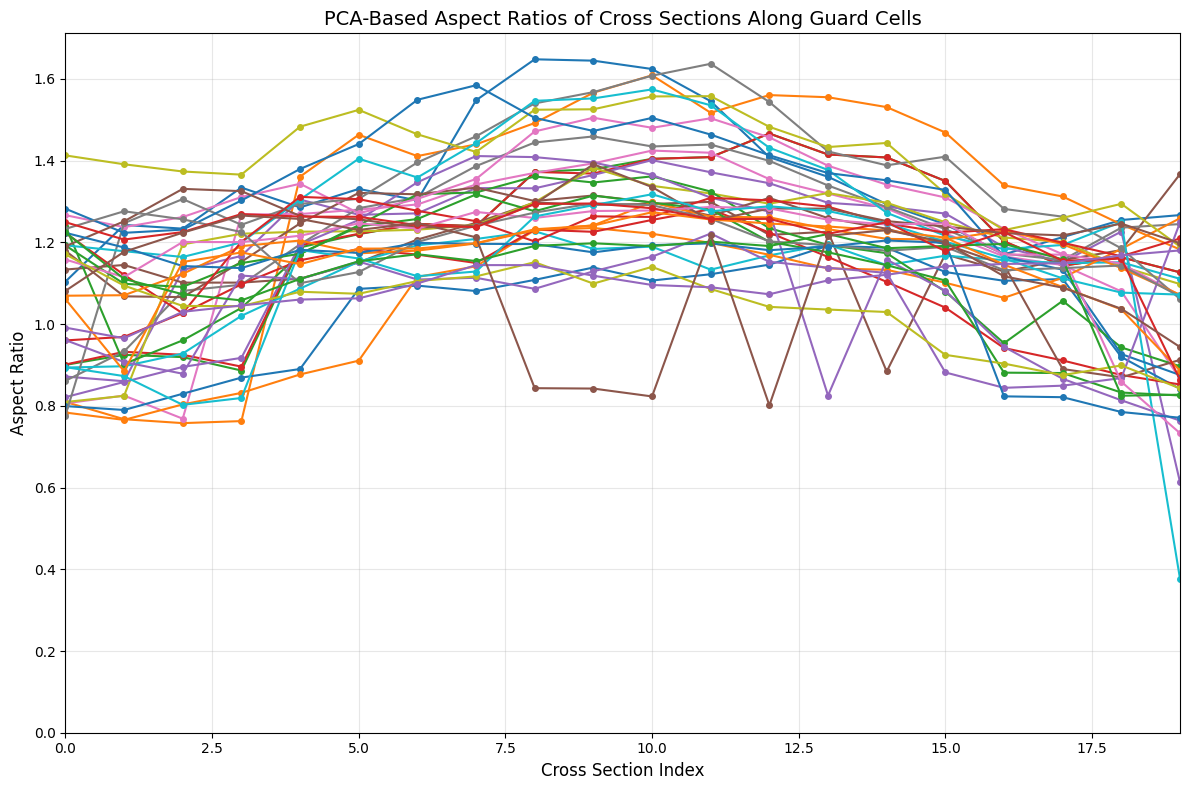

In [20]:
# Create file list for labels
s = [f"{file}_{side}" for file in files for side in ["single_a", "single_b"]]

# Extract aspect ratios from all_data
aspect_ratios_list = [data['cross_sections']['aspect_ratios'] for data in all_data]

# Plot the PCA-based aspect ratios with better formatting
plt.figure(figsize=(12, 8))

for ar, file_name in zip(aspect_ratios_list, s):
    plt.plot(ar, '-o', linewidth=1.5, markersize=4, label=file_name)

plt.xlabel('Cross Section Index', fontsize=12)
plt.ylabel('Aspect Ratio', fontsize=12)
plt.title('PCA-Based Aspect Ratios of Cross Sections Along Guard Cells', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xlim(0, 19)  # Assuming 20 sections
plt.ylim(bottom=0)  # Start y-axis at 0

# Add legend in a separate box to the right
plt.tight_layout()

# Save the figure
plt.savefig("pca_aspect_ratios.png", dpi=300, bbox_inches='tight')
plt.show()

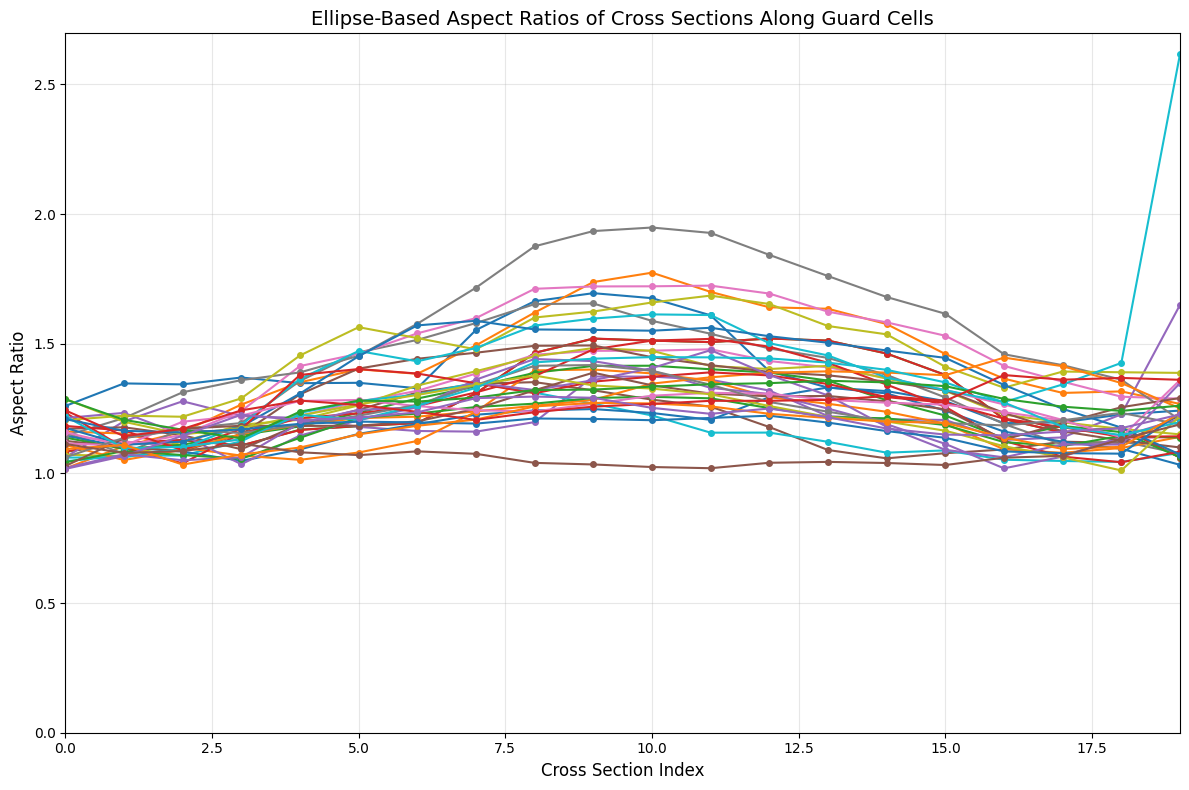

In [21]:
# Extract ellipse aspect ratios from all_data
ellipse_aspect_ratios_list = []
for data in all_data:
    ellipse_ars = []
    for ellipse_fit in data['cross_sections']['ellipse_fits']:
        if ellipse_fit is not None and 'aspect_ratio' in ellipse_fit:
            ellipse_ars.append(ellipse_fit['aspect_ratio'])
        else:
            ellipse_ars.append(np.nan)
    ellipse_aspect_ratios_list.append(ellipse_ars)

# Plot the ellipse-based aspect ratios with better formatting
plt.figure(figsize=(12, 8))

for ar, file_name in zip(ellipse_aspect_ratios_list, s):
    plt.plot(ar, '-o', linewidth=1.5, markersize=4, label=file_name)

plt.xlabel('Cross Section Index', fontsize=12)
plt.ylabel('Aspect Ratio', fontsize=12)
plt.title('Ellipse-Based Aspect Ratios of Cross Sections Along Guard Cells', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xlim(0, 19)  # Assuming 20 sections
plt.ylim(bottom=0)  # Start y-axis at 0

# Add legend in a separate box to the right
plt.tight_layout()

# Save the figure
plt.savefig("ellipse_aspect_ratios.png", dpi=300, bbox_inches='tight')
plt.show()

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Define variables to determine plot layout
n_meshes = len(aspect_ratios_list)
n_sections = len(aspect_ratios_list[0]) if n_meshes > 0 else 0

# PLOT 1: All cross sections
if all_sections_2d_points:
    n_cols = 5  # Number of columns in the grid
    n_rows = 4  # Show 4 rows (adjust as needed)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows), squeeze=False)
    plt.suptitle('Cross Sections at Different Positions Along Guard Cells', fontsize=16)
    
    # Use a color cycle to distinguish meshes
    colors = plt.cm.tab10(np.linspace(0, 1, n_meshes))
    
    # Add a small legend showing which color corresponds to which file
    legend_ax = fig.add_axes([0.15, 0.005, 0.7, 0.03])  # [left, bottom, width, height]
    legend_ax.axis('off')
    for j, file_name in enumerate(files):
        legend_ax.plot([], [], color=colors[j], label=file_name)
    legend_ax.legend(loc='center', ncol=6, fontsize=8)
    
    # Plot each cross section at each index
    for i in range(min(n_rows * n_cols, n_sections)):
        ax = axes[i // n_cols, i % n_cols]
        for j in range(n_meshes):
            points_2d = all_sections_2d_points[j][i]
            if points_2d is not None and len(points_2d) > 0:
                # Plot each shape with its corresponding color
                ax.plot(points_2d[:, 0], points_2d[:, 1], color=colors[j], alpha=0.7)
        
        ax.set_title(f'Section {i}')
        ax.axis('equal')
        ax.grid(True, linestyle='--', alpha=0.3)
    
    # Hide any unused subplots
    for k in range(n_rows * n_cols):
        if k >= n_sections:
            axes[k // n_cols, k % n_cols].axis('off')
    
    plt.tight_layout(rect=[0, 0.04, 1, 0.96])
    plt.savefig("all_cross_sections_grid.png", dpi=300)
    plt.show()

# PLOT 2: All fitted ellipses
if all_ellipses:
    n_cols = 5  # Number of columns in the grid
    n_rows = 4  # Show 4 rows (adjust as needed)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows), squeeze=False)
    plt.suptitle('Fitted Ellipses at Different Positions Along Guard Cells', fontsize=16)
    
    # Use the same color cycle as the previous plot
    colors = plt.cm.tab10(np.linspace(0, 1, n_meshes))
    
    # Add a small legend showing which color corresponds to which file
    legend_ax = fig.add_axes([0.15, 0.005, 0.7, 0.03])  # [left, bottom, width, height]
    legend_ax.axis('off')
    for j, file_name in enumerate(files):
        legend_ax.plot([], [], color=colors[j], label=file_name)
    legend_ax.legend(loc='center', ncol=6, fontsize=8)
    
    # Plot each ellipse at each index
    for i in range(min(n_rows * n_cols, n_sections)):
        ax = axes[i // n_cols, i % n_cols]
        for j in range(n_meshes):
            if j < len(all_ellipses) and i < len(all_ellipses[j]) and all_ellipses[j][i] is not None:
                # Extract ellipse data
                ellipse_data = all_ellipses[j][i]
                
                # Check if ellipse_data is a tuple (format might vary based on your implementation)
                if isinstance(ellipse_data, tuple) and len(ellipse_data) >= 2:
                    points_2d, ellipse_points = ellipse_data[0], ellipse_data[1]
                    
                    # Plot the original points lightly
                    ax.scatter(points_2d[:, 0], points_2d[:, 1], s=5, color=colors[j], alpha=0.3)
                    
                    # Plot the fitted ellipse
                    ax.plot(ellipse_points[:, 0], ellipse_points[:, 1], color=colors[j], linewidth=1.5)
                elif isinstance(ellipse_data, dict) and 'points' in ellipse_data:
                    # Alternative format where ellipse_data is a dictionary
                    ellipse_points = np.array(ellipse_data['points'])
                    ax.plot(ellipse_points[:, 0], ellipse_points[:, 1], color=colors[j], linewidth=1.5)
        
        ax.set_title(f'Section {i}')
        ax.axis('equal')
        ax.grid(True, linestyle='--', alpha=0.3)
    
    # Hide any unused subplots
    for k in range(n_rows * n_cols):
        if k >= n_sections:
            axes[k // n_cols, k % n_cols].axis('off')
    
    plt.tight_layout(rect=[0, 0.04, 1, 0.96])
    plt.savefig("all_fitted_ellipses_grid.png", dpi=300)
    plt.show()

# PLOT 3: Aspect ratios for each mesh
plt.figure(figsize=(10, 6))
# Create file names for legend if not already available
s = mesh_names if 'mesh_names' in locals() else [f"{file}_{side}" for file in files for side in ["single_a", "single_b"]]

# Plot PCA-based aspect ratios
for ar, file_name in zip(aspect_ratios_list, s):
    plt.plot(range(len(ar)), ar, '-o', linewidth=1.5, markersize=4, label=file_name)

plt.xlabel('Cross Section Index')
plt.ylabel('Aspect Ratio')
plt.title('Aspect Ratios of Cross Sections Along Guard Cells')
plt.grid(True)
plt.xlim(0, n_sections-1)
plt.ylim(bottom=0)  # Start y-axis at 0 for better comparison

# Add legend in a good position with smaller font
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig("aspect_ratios_plot.png", dpi=300)
plt.show()

# PLOT 4 (Optional): Ellipse-based aspect ratios if available
if 'ellipse_aspect_ratios_list' in locals() and len(ellipse_aspect_ratios_list) > 0:
    plt.figure(figsize=(10, 6))
    
    for ar, file_name in zip(ellipse_aspect_ratios_list, s):
        plt.plot(range(len(ar)), ar, '-o', linewidth=1.5, markersize=4, label=file_name)
    
    plt.xlabel('Cross Section Index')
    plt.ylabel('Aspect Ratio')
    plt.title('Ellipse-Based Aspect Ratios of Cross Sections Along Guard Cells')
    plt.grid(True)
    plt.xlim(0, n_sections-1)
    plt.ylim(bottom=0)  # Start y-axis at 0 for better comparison
    
    # Add legend in a good position with smaller font
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.savefig("ellipse_aspect_ratios_plot.png", dpi=300)
    plt.show()

NameError: name 'aspect_ratios_list' is not defined

In [ ]:
def visualize_orientation_consistency(all_sections_2d_points, all_ellipses, pca_components, mesh_idx=0):
    """Visualize PCA and ellipse orientations with consistent directions."""
    fig, axes = plt.subplots(4, 5, figsize=(15, 12), squeeze=False)
    
    for i in range(min(20, len(all_sections_2d_points[mesh_idx]))):
        ax = axes[i // 5, i % 5]
        points = all_sections_2d_points[mesh_idx][i]
        ellipse_data = all_ellipses[mesh_idx][i]
        
        if points is not None and len(points) > 0:
            # Plot points
            ax.scatter(points[:, 0], points[:, 1], s=10, c='blue', alpha=0.7)
            
            # Calculate PCA directly on points (instead of using pre-calculated components)
            pca = PCA(n_components=2)
            pca.fit(points)
            centroid = np.mean(points, axis=0)
            
            # Determine consistent orientation
            # Using X-axis as reference for horizontal alignment
            x_axis = np.array([1, 0])
            
            # Check which component is more horizontally aligned
            comp0, comp1 = pca.components_
            dot0_x = np.abs(np.dot(comp0, x_axis))
            dot1_x = np.abs(np.dot(comp1, x_axis))
            
            # Assign major/minor based on horizontal alignment
            if dot0_x >= dot1_x:
                # Make comp0 point right (positive x)
                main_axis = comp0 if np.dot(comp0, x_axis) > 0 else -comp0
                minor_axis = comp1 if np.cross(main_axis, comp1) > 0 else -comp1
                main_std, minor_std = np.sqrt(pca.explained_variance_[0]), np.sqrt(pca.explained_variance_[1])
            else:
                # Make comp1 point right (positive x)
                main_axis = comp1 if np.dot(comp1, x_axis) > 0 else -comp1
                minor_axis = comp0 if np.cross(main_axis, comp0) > 0 else -comp0
                main_std, minor_std = np.sqrt(pca.explained_variance_[1]), np.sqrt(pca.explained_variance_[0])
            
            # Plot PCA axes
            scale = 3.0
            ax.arrow(centroid[0], centroid[1], 
                     main_axis[0]*scale, main_axis[1]*scale, 
                     color='green', width=0.1, head_width=0.3,
                     length_includes_head=True, label='PCA main')
            
            ax.arrow(centroid[0], centroid[1], 
                     minor_axis[0]*scale, minor_axis[1]*scale, 
                     color='lime', width=0.1, head_width=0.3,
                     length_includes_head=True, label='PCA minor')
            
            # Plot ellipse with CONSISTENT axes
            if ellipse_data is not None:
                _, ellipse_points, params = ellipse_data[:3]
                xc, yc, a, b, theta = params
                
                # Plot the fitted ellipse
                ax.plot(ellipse_points[:, 0], ellipse_points[:, 1], 'r-', lw=1.5)
                
                # Use the PCA-determined axes directions for ellipse
                # But use the ellipse-determined axis lengths
                ax.arrow(xc, yc, main_axis[0]*a, main_axis[1]*a, 
                         color='red', width=0.1, head_width=0.3, 
                         length_includes_head=True, label='Ellipse a')
                
                ax.arrow(xc, yc, minor_axis[0]*b, minor_axis[1]*b, 
                         color='orange', width=0.1, head_width=0.3,
                         length_includes_head=True, label='Ellipse b')
                
                # Calculate consistent aspect ratio
                aspect_ratio = a/b if a > b else b/a
                ax.set_title(f"Section {i} (AR: {aspect_ratio:.2f})")
            
            ax.set_aspect('equal')
            ax.grid(True, alpha=0.3)
            
            # Add legend to first plot only
            if i == 0:
                ax.legend(fontsize=8)
    
    plt.tight_layout()
    plt.suptitle(f"PCA vs Ellipse Orientation Comparison - Mesh {mesh_idx}", y=1.02)
    plt.savefig(f"orientation_check_mesh_{mesh_idx}.png", dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
# First, you need to create the pca_components list from your existing data
pca_components = []

for mesh_idx, mesh_sections in enumerate(all_sections_2d_points):
    mesh_pca_components = []
    for section_idx, section_points in enumerate(mesh_sections):
        if section_points is not None and len(section_points) >= 3:
            # Get the corresponding ellipse data if available
            ellipse_data = all_ellipses[mesh_idx][section_idx] if section_idx < len(all_ellipses[mesh_idx]) else None
            
            # If ellipse data exists, extract components
            if ellipse_data is not None and isinstance(ellipse_data, tuple) and len(ellipse_data) >= 3:
                # Perform PCA on the section points
                pca = PCA(n_components=2)
                pca.fit(section_points)
                mesh_pca_components.append(pca.components_)
            else:
                mesh_pca_components.append(None)
        else:
            mesh_pca_components.append(None)
    pca_components.append(mesh_pca_components)

# Now call the function with the correct variable names
visualize_orientation_consistency(all_sections_2d_points, all_ellipses, pca_components, mesh_idx=0)

In [ ]:
def plot_cross_sections_with_metrics(all_sections_2d, all_ellipses, mesh_indices=None, 
                                    start_section=0, end_section=None, n_cols=4, figsize=(15, 10),
                                    mesh_names=None, save_metrics=True, output_prefix="cross_section_metrics"):
    """
    Plot cross-sections with their fitted ellipses, ensuring consistent axis orientation.
    Also calculates and optionally saves metrics including aspect ratios and areas.
    
    Parameters:
    -----------
    all_sections_2d : list
        List of 2D cross-section points for each mesh
    all_ellipses : list
        List of ellipse data for each mesh
    mesh_indices : list, optional
        Indices of meshes to visualize. If None, uses first mesh.
    start_section : int
        First section index to show
    end_section : int
        Last section index to show (exclusive). If None, shows all sections.
    n_cols : int
        Number of columns in the plot grid
    figsize : tuple
        Figure size
    mesh_names : list, optional
        List of names for each mesh. If None, uses index-based names.
    save_metrics : bool
        Whether to save metrics to CSV files
    output_prefix : str
        Prefix for output files
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    from matplotlib.path import Path
    
    # Reference vectors for consistent orientation
    global_reference_axis = np.array([1, 0, 0])  # For horizontal alignment fallback
    pattern_reference = np.array([1.0, 0.0, 1.0])  # Diagonal pattern in X-Z plane
    pattern_reference = pattern_reference / np.linalg.norm(pattern_reference)  # Normalize
    
    # Helper function to determine major/minor axes based on diagonal pattern
    def determine_ellipse_axes(axis1_vec_2d, axis2_vec_2d, a, b, theta):
        """Determine major/minor axes based on diagonal pattern alignment."""
        # Create 3D vectors from 2D ellipse axes (assuming XZ plane projection)
        # This is an approximation since we don't have the original 3D basis
        axis1_vec_3d = np.array([axis1_vec_2d[0], 0, axis1_vec_2d[1]])
        axis2_vec_3d = np.array([axis2_vec_2d[0], 0, axis2_vec_2d[1]])
        
        # Normalize for proper dot product comparison
        axis1_vec_3d = axis1_vec_3d / np.linalg.norm(axis1_vec_3d)
        axis2_vec_3d = axis2_vec_3d / np.linalg.norm(axis2_vec_3d)
        
        # Check alignment with pattern reference in both directions
        dot1_pos = np.abs(np.dot(axis1_vec_3d, pattern_reference))
        dot2_pos = np.abs(np.dot(axis2_vec_3d, pattern_reference))
        
        # The axis more aligned with the pattern is the major axis
        if dot1_pos >= dot2_pos:
            # First axis (a) is more aligned with pattern, so it's major
            major_len, major_cos, major_sin = a, np.cos(theta), np.sin(theta)
            minor_len, minor_cos, minor_sin = b, -np.sin(theta), np.cos(theta)
        else:
            # Second axis (b) is more aligned with pattern, so it's major
            major_len, major_cos, major_sin = b, -np.sin(theta), np.cos(theta)
            minor_len, minor_cos, minor_sin = a, np.cos(theta), np.sin(theta)
            
        return major_len, minor_len, major_cos, major_sin, minor_cos, minor_sin
    
    # Default to first mesh if no indices provided
    if mesh_indices is None:
        mesh_indices = [0]
    
    for mesh_idx in mesh_indices:
        if mesh_idx >= len(all_sections_2d) or mesh_idx >= len(all_ellipses):
            print(f"Index {mesh_idx} is out of range")
            continue
            
        sections = all_sections_2d[mesh_idx]
        ellipses_data = all_ellipses[mesh_idx]
        
        # Get mesh name for labeling
        if mesh_names is not None and mesh_idx < len(mesh_names):
            mesh_name = mesh_names[mesh_idx]
        else:
            mesh_name = f"Mesh_{mesh_idx}"
        
        # Determine which sections to plot
        if end_section is None:
            end_section = len(sections)
        
        # Get valid section indices within the specified range
        valid_sections = []
        for i in range(start_section, min(end_section, len(sections))):
            if sections[i] is not None:  # We'll handle None ellipses separately
                valid_sections.append(i)
        
        if not valid_sections:
            print(f"No valid sections found for mesh {mesh_idx} in the specified range")
            continue
        
        # Create the grid of subplots
        n_plots = len(valid_sections)
        n_rows = int(np.ceil(n_plots / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, squeeze=False)
        
        # Storage for metrics
        metrics = {
            'section_idx': [],
            'aspect_ratio': [],
            'area_polygon': [],  # Area of the actual polygon
            'area_ellipse': [],  # Area of the fitted ellipse
            'major_axis_length': [],
            'minor_axis_length': []
        }
        
        # Plot each valid section with its ellipse
        for i, section_idx in enumerate(valid_sections):
            row, col = i // n_cols, i % n_cols
            ax = axes[row, col]
            
            # Get section points
            points = sections[section_idx]
            
            if points is not None and len(points) >= 3:
                # Calculate polygon area using Shoelace formula
                polygon_area = 0.0
                # Add first point at the end to close the loop if needed
                if not np.array_equal(points[0], points[-1]):
                    points_closed = np.vstack([points, points[0]])
                else:
                    points_closed = points
                
                # Calculate area using Shoelace formula
                x = points_closed[:, 0]
                y = points_closed[:, 1]
                polygon_area = 0.5 * np.abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))
                
                # Plot the cross-section points
                ax.scatter(points[:, 0], points[:, 1], s=15, c='blue', alpha=0.7, label='Points')
                
                # Get ellipse data
                ellipse_data = ellipses_data[section_idx] if section_idx < len(ellipses_data) else None
                
                # If we have valid ellipse data, plot it
                if ellipse_data is not None:
                    points_2d, ellipse_points, params, _ = ellipse_data
                    xc, yc, a, b, theta = params
                    
                    # Plot the ellipse
                    ax.plot(ellipse_points[:, 0], ellipse_points[:, 1], 'r-', lw=2, label='Fitted Ellipse')
                    
                    # First axis vector in 2D (corresponds to 'a')
                    axis1_vec_2d = np.array([np.cos(theta), np.sin(theta)])
                    # Second axis vector in 2D (corresponds to 'b')
                    axis2_vec_2d = np.array([-np.sin(theta), np.cos(theta)])
                    
                    # Use the pattern-based approach to determine major/minor axes
                    major_len, minor_len, major_cos, major_sin, minor_cos, minor_sin = determine_ellipse_axes(
                        axis1_vec_2d, axis2_vec_2d, a, b, theta
                    )
                    
                    # Calculate ellipse area
                    ellipse_area = np.pi * major_len * minor_len
                    
                    # Draw the major axis (pattern-aligned, green)
                    ax.plot([xc - major_len*major_cos, xc + major_len*major_cos],
                            [yc - major_len*major_sin, yc + major_len*major_sin], 
                            'g-', lw=1.5, label='Major axis' if i == 0 else None)
                    
                    # Draw the minor axis (perpendicular, blue)
                    ax.plot([xc - minor_len*minor_cos, xc + minor_len*minor_cos],
                            [yc - minor_len*minor_sin, yc + minor_len*minor_sin], 
                            'b-', lw=1.5, label='Minor axis' if i == 0 else None)
                    
                    # Calculate aspect ratio
                    aspect_ratio = major_len / minor_len
                    
                    # Store metrics
                    metrics['section_idx'].append(section_idx)
                    metrics['aspect_ratio'].append(aspect_ratio)
                    metrics['area_polygon'].append(polygon_area)
                    metrics['area_ellipse'].append(ellipse_area)
                    metrics['major_axis_length'].append(major_len)
                    metrics['minor_axis_length'].append(minor_len)
                    
                    # Add aspect ratio and area text
                    ax.text(0.05, 0.95, f"AR: {aspect_ratio:.2f}", transform=ax.transAxes,
                            va='top', ha='left', bbox=dict(facecolor='white', alpha=0.7))
                    ax.text(0.05, 0.85, f"Area: {ellipse_area:.2f}", transform=ax.transAxes,
                            va='top', ha='left', bbox=dict(facecolor='white', alpha=0.7))
                else:
                    # If no ellipse data, just store polygon info
                    metrics['section_idx'].append(section_idx)
                    metrics['aspect_ratio'].append(np.nan)
                    metrics['area_polygon'].append(polygon_area)
                    metrics['area_ellipse'].append(np.nan)
                    metrics['major_axis_length'].append(np.nan)
                    metrics['minor_axis_length'].append(np.nan)
            
            ax.set_title(f'Section {section_idx}')
            ax.set_aspect('equal')
            ax.grid(True, linestyle='--', alpha=0.5)
            
            # Add legend to the first plot only
            if i == 0:
                ax.legend(loc='lower right', fontsize=8)
        
        # Hide unused subplots
        for i in range(len(valid_sections), n_rows * n_cols):
            row, col = i // n_cols, i % n_cols
            axes[row, col].axis('off')
        
        # Save metrics to CSV if requested
        if save_metrics and metrics['section_idx']:
            df = pd.DataFrame(metrics)
            csv_filename = f"{output_prefix}_{mesh_name}.csv"
            df.to_csv(csv_filename, index=False)
            print(f"Saved metrics to {csv_filename}")
        
        # Add a title for the whole figure
        plt.suptitle(f'Cross-sections with Metrics - {mesh_name}', fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        
        # Save the figure
        plt.savefig(f"{output_prefix}_{mesh_name}_plot.png", dpi=300)
        plt.show()
        
        return metrics

In [ ]:
files = ["Ac_DA_1_2","Ac_DA_1_3","Ac_DA_1_4","Ac_DA_1_5","Ac_DA_1_6","Ac_DA_1_8","Ac_DA_2_1", "Ac_DA_2_3","Ac_DA_2_4","Ac_DA_2_6a","Ac_DA_2_6b", "Ac_DA_2_7","Ac_DA_3_1", "Ac_DA_3_2", "Ac_DA_3_3", "Ac_DA_3_4","Ac_DA_3_6", "Ac_DA_3_7"]
path = "Meshes/Onion meshes/"
aspect_ratios_list = []
ellipse_aspect_ratios_list = []  # For ellipse-based aspect ratios
all_sections_2d_points = []
all_ellipses = []  # To store ellipse data for visualization
global_reference_axis = np.array([1, 0, 0])
# Define a diagonal pattern reference in the X-Z plane
pattern_reference = np.array([1.0, 0.0, 1.0])  # Diagonal pattern in X-Z plane
pattern_reference = pattern_reference / np.linalg.norm(pattern_reference)  # Normalize

# Import for ellipse fitting
from skimage.measure import EllipseModel

for file in files:
    for side in ["single_a", "single_b"]:
        mesh_path = f"{path}{file}/{file}_{side}.obj"
        mesh = trimesh.load(mesh_path, process=True)
        
        # Align the mesh to the Y-axis and center it
        mesh = align_mesh_to_y_axis(mesh)
        
        # First, find the outer edge to determine orientation
        outer_points_check = find_outer_edge(mesh, smoothing=50)
        
        # If the cell's outer edge is on the negative x-side, flip the entire mesh
        if np.mean(outer_points_check[:, 0]) < 0:
            mesh.vertices[:, 0] *= -1
        
        # Now that all meshes are consistently oriented, proceed with analysis
        outer_points = find_outer_edge(mesh, smoothing=50)
        
        # Process the outer curve in one step
        outer_curve_projected = create_projected_curve(
            mesh, 
            outer_points,
            smooth=50,
            n_points=120,
            end_segment_size=10
        )
        
        # Create the centreline from the start and end circles
        section_midpoint = np.mean(outer_curve_projected, axis=0)
        centreline, centreline_trace = create_bezier_centreline(
            outer_curve_projected[0], section_midpoint, outer_curve_projected[-1], curve_points=50
        )
        
        # Define indices for cross-sections for the CURRENT centreline
        n_sections = 20
        end_margin_points = 3  # Avoids unstable sections at the very ends
        start_index = end_margin_points
        end_index = len(centreline) - 1 - end_margin_points
        indices = np.linspace(start_index, end_index, n_sections, dtype=int)
        all_section_points = get_cross_section_points(mesh, centreline, indices)

        # Pre-calculate tangents for all centreline points
        tangents = np.gradient(centreline, axis=0)
        tangents /= np.linalg.norm(tangents, axis=1, keepdims=True)
        
        aspect_ratios = []
        ellipse_aspect_ratios = []  # New list for ellipse-based aspect ratios
        current_mesh_sections_2d = []
        current_ellipses = []  # Store ellipse data for this mesh
        
        # Process each cross-section using pattern-based axis determination
        for i, section_points in enumerate(all_section_points):
            # Get the corresponding tangent and midpoint for this section
            idx = indices[i]
            tangent = tangents[idx]
            midpoint = centreline[idx]

            if len(section_points) >= 5:  # Need at least 5 points for ellipse fitting
                # --- Aspect Ratio Calculation with PATTERN-BASED axis identification ---
                pca = PCA(n_components=2)
                pca.fit(section_points)
                std_devs = np.sqrt(pca.explained_variance_)
                
                # Get PCA components
                component_0 = pca.components_[0]
                component_1 = pca.components_[1]
                
                # Check alignment with pattern reference in both positive and negative directions
                dot_0_pos = np.dot(component_0, pattern_reference)
                dot_0_neg = np.dot(-component_0, pattern_reference)
                dot_1_pos = np.dot(component_1, pattern_reference)
                dot_1_neg = np.dot(-component_1, pattern_reference)
                
                # Use the maximum absolute alignment
                dot_0 = dot_0_pos if dot_0_pos > dot_0_neg else dot_0_neg
                dot_1 = dot_1_pos if dot_1_pos > dot_1_neg else dot_1_neg
                
                # The component more aligned with our pattern is the major axis
                if dot_0 >= dot_1:
                    # Component 0 is more aligned with pattern, so it's our major axis
                    main_axis_vec = component_0 if dot_0_pos > dot_0_neg else -component_0
                    # Make minor axis perpendicular and properly oriented
                    minor_axis_vec = component_1 if np.cross(main_axis_vec, component_1)[1] > 0 else -component_1
                    main_axis_std, minor_axis_std = std_devs[0], std_devs[1]
                else:
                    # Component 1 is more aligned with pattern, so it's our major axis
                    main_axis_vec = component_1 if dot_1_pos > dot_1_neg else -component_1
                    # Make minor axis perpendicular and properly oriented
                    minor_axis_vec = component_0 if np.cross(main_axis_vec, component_0)[1] > 0 else -component_0
                    minor_axis_std, main_axis_std = std_devs[1], std_devs[0]
                
                # --- 2D Projection for ellipse fitting ---
                # Create a consistent 2D basis using the main and minor axes
                centered = section_points - np.mean(section_points, axis=0)
                x_coords = centered @ main_axis_vec
                y_coords = centered @ minor_axis_vec
                points_2d = np.column_stack([x_coords, y_coords])
                
                # --- ELLIPSE FITTING WITH PATTERN-BASED AXIS ALIGNMENT ---
                try:
                    ellipse_model = EllipseModel()
                    # Try to fit an ellipse to the 2D points
                    if len(points_2d) >= 5 and ellipse_model.estimate(points_2d):
                        # Get ellipse parameters: center (xc, yc), semi-axes lengths (a, b), angle
                        params = ellipse_model.params
                        xc, yc, a, b, theta = params
                        
                        # Create ellipse axes vectors in 2D
                        # First axis (corresponding to 'a')
                        axis1_vec_2d = np.array([np.cos(theta), np.sin(theta)])
                        # Second axis (corresponding to 'b')
                        axis2_vec_2d = np.array([-np.sin(theta), np.cos(theta)])
                        
                        # Map these 2D axes to 3D using the original basis vectors
                        axis1_vec_3d = main_axis_vec * axis1_vec_2d[0] + minor_axis_vec * axis1_vec_2d[1]
                        axis2_vec_3d = main_axis_vec * axis2_vec_2d[0] + minor_axis_vec * axis2_vec_2d[1]
                        
                        # Determine which axis is more aligned with our pattern reference
                        dot1_pattern = np.abs(np.dot(axis1_vec_3d, pattern_reference))
                        dot2_pattern = np.abs(np.dot(axis2_vec_3d, pattern_reference))
                        
                        # Assign major/minor based on pattern alignment
                        if dot1_pattern >= dot2_pattern:
                            # Axis 1 is more pattern-aligned, so it's the main axis
                            main_axis_len, minor_axis_len = a, b
                        else:
                            # Axis 2 is more pattern-aligned, so it's the main axis
                            main_axis_len, minor_axis_len = b, a
                        
                        # Calculate aspect ratio based on pattern alignment
                        if minor_axis_len > 1e-9:
                            ellipse_ar = main_axis_len / minor_axis_len
                            ellipse_aspect_ratios.append(ellipse_ar)
                        else:
                            ellipse_aspect_ratios.append(np.nan)
                            
                        # Generate points along the ellipse for visualization
                        t = np.linspace(0, 2*np.pi, 100)
                        ellipse_x = xc + a * np.cos(t) * np.cos(theta) - b * np.sin(t) * np.sin(theta)
                        ellipse_y = yc + a * np.cos(t) * np.sin(theta) + b * np.sin(t) * np.cos(theta)
                        ellipse_points = np.column_stack([ellipse_x, ellipse_y])
                        
                        # Store the ellipse data with flag for which axis is main (pattern-aligned)
                        current_ellipses.append((points_2d, ellipse_points, params, dot1_pattern >= dot2_pattern))
                    else:
                        # Ellipse fitting failed, use NaN for ellipse AR
                        ellipse_aspect_ratios.append(np.nan)
                        current_ellipses.append(None)
                except Exception as e:
                    print(f"Ellipse fitting failed for {file}_{side} section {i}: {e}")
                    ellipse_aspect_ratios.append(np.nan)
                    current_ellipses.append(None)
                
                # Original PCA-based aspect ratio (keep for comparison)
                if minor_axis_std > 1e-9:
                    aspect_ratios.append(main_axis_std / minor_axis_std)
                else:
                    aspect_ratios.append(np.nan)

                # Store the 2D projection
                current_mesh_sections_2d.append(points_2d)
            else:
                aspect_ratios.append(np.nan)
                ellipse_aspect_ratios.append(np.nan)
                current_mesh_sections_2d.append(None)  # Add a placeholder
                current_ellipses.append(None)

        aspect_ratios_list.append(aspect_ratios)
        ellipse_aspect_ratios_list.append(ellipse_aspect_ratios)  # Store ellipse ARs
        all_sections_2d_points.append(current_mesh_sections_2d)
        all_ellipses.append(current_ellipses)  # Store ellipse data
        
        # Print stats for both methods
        print(f"Processed {file}_{side}:")
        print(f"  PCA AR:     Mean = {np.nanmean(aspect_ratios):.3f}, Median = {np.nanmedian(aspect_ratios):.3f}")
        print(f"  Ellipse AR: Mean = {np.nanmean(ellipse_aspect_ratios):.3f}, Median = {np.nanmedian(ellipse_aspect_ratios):.3f}")

In [ ]:
# Example usage for a single mesh
metrics = plot_cross_sections_with_metrics(
    all_sections_2d_points, all_ellipses, 
    mesh_indices=[0], start_section=0, end_section=19, 
    n_cols=4, figsize=(16, 12),
    mesh_names=s, save_metrics=True, output_prefix="results/cross_section"
)

# Or analyze all files at once
all_metrics = analyze_all_cross_sections(
    files=files,
    path=path,
    output_dir="cross_section_results"
)

# Create a combined plot with aspect ratios and areas
import matplotlib.pyplot as plt
import numpy as np

# Extract a specific file's metrics
file_key = f"{files[0]}_single_a"
file_metrics = all_metrics[file_key]['metrics']

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot aspect ratio
ax1.set_xlabel('Section Index')
ax1.set_ylabel('Aspect Ratio', color='tab:blue')
ax1.plot(file_metrics['section_idx'], file_metrics['aspect_ratio'], 'o-', color='tab:blue', label='Aspect Ratio')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Create second y-axis for area
ax2 = ax1.twinx()
ax2.set_ylabel('Area', color='tab:red')
ax2.plot(file_metrics['section_idx'], file_metrics['area_ellipse'], 's-', color='tab:red', label='Area')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Add title and adjust layout
plt.title(f'Cross-Section Metrics - {file_key}')
fig.tight_layout()
plt.grid(True)
plt.savefig(f"combined_metrics_{file_key}.png", dpi=300)
plt.show()

In [ ]:
## Create our file list
s = [f"{file}_{side}" for file in files for side in ["single_a", "single_b"]]

# Plot the aspect ratios for each mesh
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
for ar, file_name in zip(aspect_ratios_list, s):
    plt.plot(ar, label=file_name)  # Use individual file name as label
plt.xlabel('Cross Section Index')
plt.ylabel('Aspect Ratio')
plt.title('Aspect Ratios of Cross Sections Along Guard Cells')
plt.grid()

# Plot the ellipse-based aspect ratios
plt.figure(figsize=(10, 6))
for ar, file_name in zip(ellipse_aspect_ratios_list, s):
    plt.plot(ar, label=file_name)  # Use individual file name as label
plt.xlabel('Cross Section Index')
plt.ylabel('Aspect Ratio')
plt.title('Ellipse-Based Aspect Ratios of Cross Sections Along Guard Cells')
plt.xlim(0, 19)  # Assuming 20 sections
plt.grid()

In [ ]:
## Run all of functions, step by step.

mesh_path = "Meshes/Onion meshes/Ac_DA_1_2/Ac_DA_1_2_single_a.obj"
#mesh_path = "/home/tomkinsm/stomata-air-mattress/arabidopsis/myrYFP_38.6_ABA+dark_t120_EDITED_GCS_ONLY_MESH_single_cell.obj"
mesh = trimesh.load(mesh_path, process=True)

## Align the mesh to the Y-axis and center it
mesh = align_mesh_to_y_axis(mesh)

visualize_mesh(mesh, title="Original Mesh")

# Align the mesh to the Y-axis and center it
mesh = align_mesh_to_y_axis(mesh)

# First, find the outer edge to determine orientation
outer_points_check = find_outer_edge(mesh, smoothing=50)

# If the cell's outer edge is on the negative x-side, flip the entire mesh
if np.mean(outer_points_check[:, 0]) < 0:
    mesh.vertices[:, 0] *= -1

# Now that all meshes are consistently oriented, proceed with analysis
outer_points = find_outer_edge(mesh, smoothing=50)

## Create a trace from the outer points
outer_trace = go.Scatter3d(
    x=outer_points[:, 0],
    y=outer_points[:, 1],
    z=outer_points[:, 2],
    mode='lines+markers',
    marker=dict(size=4, color='green'),
    name='Smoothed Outer Points'
)

# Process the outer curve in one step
outer_curve_projected = create_projected_curve(
    mesh, 
    outer_points,
    smooth=50,
    n_points=120,
    end_segment_size=10
)

# Plot the result
outer_projected_trace = go.Scatter3d(
    x=outer_curve_projected[:,0], 
    y=outer_curve_projected[:,1], 
    z=outer_curve_projected[:,2],
    mode='lines+markers', 
    marker=dict(size=4, color='green'), 
    name='Outer Curve Projected'
)

midpoint_trace, section_trace, section_points = get_midpoint_trace(outer_points, mesh)
#visualize_mesh(mesh, [outer_trace, midpoint_trace, section_trace], title="Outer Curve with Midpoint Cross Section")

## Add the circles at the start and end of the projected outer curve
circle_start_trace, circle_end_trace, outer_projected_trace, center_start_trace, center_end_trace, center_start, center_end = define_end_point_circles(outer_curve_projected, section_points)

visualize_mesh(mesh, [outer_projected_trace, circle_start_trace, circle_end_trace, center_start_trace, center_end_trace, midpoint_trace], title="Outer Curve Processed and Projected")

In [ ]:
## Create the centreline from the start and end circles

section_midpoint = np.mean(section_points, axis=0)

centreline, centreline_trace =  create_bezier_centreline(center_start, section_midpoint, center_end, curve_points=50)

visualize_mesh(mesh, [centreline_trace], title="Centreline from Start and End Circles")

## Create the cross sections tangential to the fitted centreline
cross_sections = create_cross_sections(mesh, centreline, n_sections=20, end_margin_points=3)
visualize_mesh(mesh, cross_sections, title="Cross Sections Tangential to Fitted Centreline")

In [ ]:


files = ["Ac_DA_1_2","Ac_DA_1_3","Ac_DA_1_4","Ac_DA_1_5","Ac_DA_1_6","Ac_DA_1_8","Ac_DA_2_1", "Ac_DA_2_3","Ac_DA_2_4","Ac_DA_2_6a","Ac_DA_2_6b", "Ac_DA_2_7","Ac_DA_3_1", "Ac_DA_3_2", "Ac_DA_3_3", "Ac_DA_3_4","Ac_DA_3_6", "Ac_DA_3_7"]
path = "Meshes/Onion meshes/"
aspect_ratios_list = []
all_sections_2d_points = []
global_reference_axis = np.array([1, 0, 0])

for file in files:
    for side in ["single_a", "single_b"]:
        mesh_path = f"{path}{file}/{file}_{side}.obj"
        mesh = trimesh.load(mesh_path, process=True)
        
        # Align the mesh to the Y-axis and center it
        mesh = align_mesh_to_y_axis(mesh)
        
        # First, find the outer edge to determine orientation
        outer_points_check = find_outer_edge(mesh, smoothing=50)
        
        # If the cell's outer edge is on the negative x-side, flip the entire mesh
        if np.mean(outer_points_check[:, 0]) < 0:
            mesh.vertices[:, 0] *= -1
        
        # Now that all meshes are consistently oriented, proceed with analysis
        outer_points = find_outer_edge(mesh, smoothing=50)
        
        # Create a trace from the outer points
        outer_trace = go.Scatter3d(
            x=outer_points[:, 0],
            y=outer_points[:, 1],
            z=outer_points[:, 2],
            mode='lines+markers',
            marker=dict(size=4, color='green'),
            name='Smoothed Outer Points'
        )
        
        # Process the outer curve in one step
        outer_curve_projected = create_projected_curve(
            mesh, 
            outer_points,
            smooth=50,
            n_points=120,
            end_segment_size=10
        )
        
        # Create the centreline from the start and end circles
        section_midpoint = np.mean(outer_curve_projected, axis=0)
        centreline, centreline_trace = create_bezier_centreline(
            outer_curve_projected[0], section_midpoint, outer_curve_projected[-1], curve_points=50
        )
        
        # Define indices for cross-sections for the CURRENT centreline
        n_sections = 20
        end_margin_points = 3  # Avoids unstable sections at the very ends
        start_index = end_margin_points
        end_index = len(centreline) - 1 - end_margin_points
        indices = np.linspace(start_index, end_index, n_sections, dtype=int)
        all_section_points = get_cross_section_points(mesh, centreline, indices)

        
        # --- Determine the reference axis for THIS CELL from its middle cross-section ---
        cell_reference_axis = np.array([1, 0, 0]) # Default fallback
        if all_section_points:
            mid_section_index = len(all_section_points) // 2
            mid_section_points = all_section_points[mid_section_index]
            if mid_section_points is not None and len(mid_section_points) >= 3:
                pca_mid = PCA(n_components=2)
                pca_mid.fit(mid_section_points)
                # The main axis of the middle section becomes the reference for this cell
                cell_reference_axis = pca_mid.components_[0]

        # Pre-calculate tangents for all centreline points
        tangents = np.gradient(centreline, axis=0)
        tangents /= np.linalg.norm(tangents, axis=1, keepdims=True)
        
        aspect_ratios = []
        current_mesh_sections_2d = []
        
        # Use the global reference axis for all calculations
        for i, section_points in enumerate(all_section_points):
            # Get the corresponding tangent and midpoint for this section
            idx = indices[i]
            tangent = tangents[idx]
            midpoint = centreline[idx]

            if len(section_points) >= 3:
                # --- Aspect Ratio Calculation (as before) ---
                pca = PCA(n_components=2)
                pca.fit(section_points)
                dot_product_0 = np.abs(np.dot(pca.components_[0], global_reference_axis))
                dot_product_1 = np.abs(np.dot(pca.components_[1], global_reference_axis))
                
                # Standard deviations are the square roots of the variances
                std_devs = np.sqrt(pca.explained_variance_)
                
                if dot_product_0 >= dot_product_1:
                    main_axis_std, minor_axis_std = std_devs[0], std_devs[1]
                else:
                    main_axis_std, minor_axis_std = std_devs[1], std_devs[0]
                
                if minor_axis_std > 1e-9:
                    # Aspect ratio is the ratio of major to minor axis lengths (std deviations)
                    aspect_ratios.append(main_axis_std / minor_axis_std)
                else:
                    aspect_ratios.append(np.nan)

                # --- 2D Projection for Plotting ---
                # Create a consistent 2D basis using the global reference axis
                v2 = global_reference_axis - np.dot(global_reference_axis, tangent) * tangent
                v2 /= np.linalg.norm(v2)
                v1 = np.cross(v2, tangent)
                
                # Project points into the new 2D coordinate system
                centered = section_points - midpoint
                x_coords = centered @ v1
                y_coords = centered @ v2
                    
                current_mesh_sections_2d.append(np.column_stack([x_coords, y_coords]))

            else:
                aspect_ratios.append(np.nan)
                current_mesh_sections_2d.append(None) # Add a placeholder

        aspect_ratios_list.append(aspect_ratios)
        all_sections_2d_points.append(current_mesh_sections_2d)

In [ ]:
files = ["Ac_DA_1_2","Ac_DA_1_3","Ac_DA_1_4","Ac_DA_1_5","Ac_DA_1_6","Ac_DA_1_8","Ac_DA_2_1", "Ac_DA_2_3","Ac_DA_2_4","Ac_DA_2_6a","Ac_DA_2_6b", "Ac_DA_2_7","Ac_DA_3_1", "Ac_DA_3_2", "Ac_DA_3_3", "Ac_DA_3_4","Ac_DA_3_6", "Ac_DA_3_7"]
path = "Meshes/Onion meshes/"
aspect_ratios_list = []
all_sections_2d_points = []
global_reference_axis = np.array([1, 0, 0])
vertical_reference = np.array([0, 0, 1])  # Z-axis for minor axis alignment

for file in files:
    for side in ["single_a", "single_b"]:
        mesh_path = f"{path}{file}/{file}_{side}.obj"
        mesh = trimesh.load(mesh_path, process=True)
        
        # Align the mesh to the Y-axis and center it
        mesh = align_mesh_to_y_axis(mesh)
        
        # First, find the outer edge to determine orientation
        outer_points_check = find_outer_edge(mesh, smoothing=50)
        
        # If the cell's outer edge is on the negative x-side, flip the entire mesh
        if np.mean(outer_points_check[:, 0]) < 0:
            mesh.vertices[:, 0] *= -1
        
        # Now that all meshes are consistently oriented, proceed with analysis
        outer_points = find_outer_edge(mesh, smoothing=50)
        
        # Create a trace from the outer points
        outer_trace = go.Scatter3d(
            x=outer_points[:, 0],
            y=outer_points[:, 1],
            z=outer_points[:, 2],
            mode='lines+markers',
            marker=dict(size=4, color='green'),
            name='Smoothed Outer Points'
        )
        
        # Process the outer curve in one step
        outer_curve_projected = create_projected_curve(
            mesh, 
            outer_points,
            smooth=50,
            n_points=120,
            end_segment_size=10
        )
        
        # Create the centreline from the start and end circles
        section_midpoint = np.mean(outer_curve_projected, axis=0)
        centreline, centreline_trace = create_bezier_centreline(
            outer_curve_projected[0], section_midpoint, outer_curve_projected[-1], curve_points=50
        )
        
        # Define indices for cross-sections for the CURRENT centreline
        n_sections = 20
        end_margin_points = 3  # Avoids unstable sections at the very ends
        start_index = end_margin_points
        end_index = len(centreline) - 1 - end_margin_points
        indices = np.linspace(start_index, end_index, n_sections, dtype=int)
        all_section_points = get_cross_section_points(mesh, centreline, indices)

        # Pre-calculate tangents for all centreline points
        tangents = np.gradient(centreline, axis=0)
        tangents /= np.linalg.norm(tangents, axis=1, keepdims=True)
        
        aspect_ratios = []
        current_mesh_sections_2d = []
        
        # Process each cross-section with Z-aligned minor axis
        for i, section_points in enumerate(all_section_points):
            # Get the corresponding tangent and midpoint for this section
            idx = indices[i]
            tangent = tangents[idx]
            midpoint = centreline[idx]

            if len(section_points) >= 3:
                # --- Aspect Ratio Calculation with Z-aligned minor axis ---
                pca = PCA(n_components=2)
                pca.fit(section_points)
                std_devs = np.sqrt(pca.explained_variance_)
                
                # REVISED: Identify which component is more aligned with the vertical axis
                # The component most aligned with Z will be the minor axis
                dot_0_vert = np.abs(np.dot(pca.components_[0], vertical_reference))
                dot_1_vert = np.abs(np.dot(pca.components_[1], vertical_reference))
                
                if dot_0_vert >= dot_1_vert:
                    # Component 0 is more aligned with Z-axis (minor)
                    minor_axis_vec = pca.components_[0] * np.sign(np.dot(pca.components_[0], vertical_reference))
                    main_axis_vec = pca.components_[1]
                    # Make sure main axis is properly oriented
                    if np.dot(main_axis_vec, global_reference_axis) < 0:
                        main_axis_vec = -main_axis_vec
                    minor_axis_std, main_axis_std = std_devs[0], std_devs[1]
                else:
                    # Component 1 is more aligned with Z-axis (minor)
                    minor_axis_vec = pca.components_[1] * np.sign(np.dot(pca.components_[1], vertical_reference))
                    main_axis_vec = pca.components_[0]
                    # Make sure main axis is properly oriented
                    if np.dot(main_axis_vec, global_reference_axis) < 0:
                        main_axis_vec = -main_axis_vec
                    minor_axis_std, main_axis_std = std_devs[1], std_devs[0]
                
                if minor_axis_std > 1e-9:
                    # Aspect ratio is the ratio of major to minor axis lengths
                    aspect_ratios.append(main_axis_std / minor_axis_std)
                else:
                    aspect_ratios.append(np.nan)

                # --- 2D Projection for Plotting ---
                # Create a consistent 2D basis using the main and minor axes for proper orientation
                # Project to 2D plane with main axis as X and minor axis as Y
                centered = section_points - np.mean(section_points, axis=0)
                x_coords = centered @ main_axis_vec
                y_coords = centered @ minor_axis_vec
                
                current_mesh_sections_2d.append(np.column_stack([x_coords, y_coords]))
            else:
                aspect_ratios.append(np.nan)
                current_mesh_sections_2d.append(None) # Add a placeholder

        aspect_ratios_list.append(aspect_ratios)
        all_sections_2d_points.append(current_mesh_sections_2d)
        
        print(f"Processed {file}_{side}: Mean aspect ratio = {np.nanmean(aspect_ratios):.3f}")

In [ ]:
# Process each cross-section with pattern-based axis identification
for i, section_points in enumerate(all_section_points):
    # Get the corresponding tangent and midpoint for this section
    idx = indices[i]
    tangent = tangents[idx]
    midpoint = centreline[idx]

    if len(section_points) >= 5:  # Need at least 5 points for ellipse fitting
        # --- Aspect Ratio Calculation with PATTERN-BASED axis identification ---
        pca = PCA(n_components=2)
        pca.fit(section_points)
        std_devs = np.sqrt(pca.explained_variance_)
        
        # This vector points from behind+below to above+front of the cell (X+ and Z+)
        pattern_reference = np.array([1.0, 0.0, 1.0])  # Float array
        pattern_reference /= np.linalg.norm(pattern_reference)
        
        # Identify which component is more aligned with the pattern reference
        component_0 = pca.components_[0]
        component_1 = pca.components_[1]
        
        # Check for alignment in both positive and negative directions
        dot_0_pos = np.dot(component_0, pattern_reference)
        dot_0_neg = np.dot(-component_0, pattern_reference)
        dot_1_pos = np.dot(component_1, pattern_reference)
        dot_1_neg = np.dot(-component_1, pattern_reference)
        
        # Use the maximum absolute alignment
        dot_0 = dot_0_pos if dot_0_pos > dot_0_neg else dot_0_neg
        dot_1 = dot_1_pos if dot_1_pos > dot_1_neg else dot_1_neg
        
        # The component more aligned with our pattern is the major axis
        if dot_0 >= dot_1:
            main_axis_vec = component_0 if dot_0_pos > dot_0_neg else -component_0
            minor_axis_vec = component_1 if np.cross(main_axis_vec, component_1)[1] > 0 else -component_1
            main_axis_std, minor_axis_std = std_devs[0], std_devs[1]
        else:
            main_axis_vec = component_1 if dot_1_pos > dot_1_neg else -component_1
            minor_axis_vec = component_0 if np.cross(main_axis_vec, component_0)[1] > 0 else -component_0
            main_axis_std, minor_axis_std = std_devs[1], std_devs[0]
        
        # --- 2D Projection for ellipse fitting ---
        # Create a consistent 2D basis using the main and minor axes
        centered = section_points - np.mean(section_points, axis=0)
        x_coords = centered @ main_axis_vec
        y_coords = centered @ minor_axis_vec
        points_2d = np.column_stack([x_coords, y_coords])
        
        # --- ELLIPSE FITTING WITH PATTERN-BASED AXIS ALIGNMENT ---
        try:
            ellipse_model = EllipseModel()
            if len(points_2d) >= 5 and ellipse_model.estimate(points_2d):
                params = ellipse_model.params
                xc, yc, a, b, theta = params
                
                # Create ellipse axes vectors in 2D
                axis1_vec_2d = np.array([np.cos(theta), np.sin(theta)])
                axis2_vec_2d = np.array([-np.sin(theta), np.cos(theta)])
                
                # Map these 2D axes to 3D using the original basis vectors
                axis1_vec_3d = main_axis_vec * axis1_vec_2d[0] + minor_axis_vec * axis1_vec_2d[1]
                axis2_vec_3d = main_axis_vec * axis2_vec_2d[0] + minor_axis_vec * axis2_vec_2d[1]
                
                # Determine which axis is more aligned with the pattern reference
                dot1_pattern = np.abs(np.dot(axis1_vec_3d, pattern_reference))
                dot2_pattern = np.abs(np.dot(axis2_vec_3d, pattern_reference))
                
                # Assign major/minor based on pattern alignment
                if dot1_pattern >= dot2_pattern:
                    # Axis 1 is more pattern-aligned, so it's the main axis
                    main_axis_len, minor_axis_len = a, b
                else:
                    # Axis 2 is more pattern-aligned, so it's the main axis
                    main_axis_len, minor_axis_len = b, a
                
                # Calculate aspect ratio
                if minor_axis_len > 1e-9:
                    ellipse_ar = main_axis_len / minor_axis_len
                    ellipse_aspect_ratios.append(ellipse_ar)
                else:
                    ellipse_aspect_ratios.append(np.nan)
                
                # Generate points along the ellipse for visualization
                t = np.linspace(0, 2*np.pi, 100)
                ellipse_x = xc + a * np.cos(t) * np.cos(theta) - b * np.sin(t) * np.sin(theta)
                ellipse_y = yc + a * np.cos(t) * np.sin(theta) + b * np.sin(t) * np.cos(theta)
                ellipse_points = np.column_stack([ellipse_x, ellipse_y])
                
                # Store the ellipse data with flag for which axis is main (pattern-aligned)
                current_ellipses.append((points_2d, ellipse_points, params, dot1_pattern >= dot2_pattern))
            else:
                ellipse_aspect_ratios.append(np.nan)
                current_ellipses.append(None)
        except Exception as e:
            print(f"Ellipse fitting failed for {file}_{side} section {i}: {e}")
            ellipse_aspect_ratios.append(np.nan)
            current_ellipses.append(None)
        
        # Original PCA-based aspect ratio
        if minor_axis_std > 1e-9:
            aspect_ratios.append(main_axis_std / minor_axis_std)
        else:
            aspect_ratios.append(np.nan)

        # Store the 2D projection
        current_mesh_sections_2d.append(points_2d)
    else:
        aspect_ratios.append(np.nan)
        ellipse_aspect_ratios.append(np.nan)
        current_mesh_sections_2d.append(None)
        current_ellipses.append(None)

In [ ]:
## Plot the cross section points for each cross section with the ellipse overlaid

def plot_cross_sections_with_ellipses(all_sections_2d, all_ellipses, mesh_indices=None, 
                                     start_section=0, end_section=None, n_cols=4, figsize=(15, 10)):
    """
    Plot cross-sections with their fitted ellipses.
    
    Parameters:
    -----------
    all_sections_2d : list
        List of 2D cross-section points for each mesh
    all_ellipses : list
        List of ellipse data for each mesh
    mesh_indices : list, optional
        Indices of meshes to visualize. If None, uses first mesh.
    start_section : int
        First section index to show
    end_section : int
        Last section index to show (exclusive). If None, shows all sections.
    n_cols : int
        Number of columns in the plot grid
    figsize : tuple
        Figure size
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Default to first mesh if no indices provided
    if mesh_indices is None:
        mesh_indices = [0]
    
    for mesh_idx in mesh_indices:
        if mesh_idx >= len(all_sections_2d) or mesh_idx >= len(all_ellipses):
            print(f"Index {mesh_idx} is out of range")
            continue
            
        sections = all_sections_2d[mesh_idx]
        ellipses_data = all_ellipses[mesh_idx]
        
        # Determine which sections to plot
        if end_section is None:
            end_section = len(sections)
        
        # Get valid section indices within the specified range
        valid_sections = []
        for i in range(start_section, min(end_section, len(sections))):
            if sections[i] is not None and ellipses_data[i] is not None:
                valid_sections.append(i)
        
        if not valid_sections:
            print(f"No valid sections found for mesh {mesh_idx} in the specified range")
            continue
        
        # Create the grid of subplots
        n_plots = len(valid_sections)
        n_rows = int(np.ceil(n_plots / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, squeeze=False)
        
        # Plot each valid section with its ellipse
        for i, section_idx in enumerate(valid_sections):
            row, col = i // n_cols, i % n_cols
            ax = axes[row, col]
            
            # Get section points and ellipse data
            points = sections[section_idx]
            ellipse_data = ellipses_data[section_idx]
            
            # Plot the cross-section points
            ax.scatter(points[:, 0], points[:, 1], s=15, c='blue', alpha=0.7, label='Points')
            
            # Plot the fitted ellipse
            if ellipse_data is not None:
                points_2d, ellipse_points, params, minor_is_first = ellipse_data
                xc, yc, a, b, theta = params
                
                # Plot the ellipse
                ax.plot(ellipse_points[:, 0], ellipse_points[:, 1], 'r-', lw=2, label='Fitted Ellipse')
                
                # Draw the major and minor axes
                cos_theta, sin_theta = np.cos(theta), np.sin(theta)
                
                # Get axis lengths based on Z-alignment
                if minor_is_first:
                    minor_len, major_len = a, b
                else:
                    minor_len, major_len = b, a
                
                # First axis (a)
                ax.plot([xc - a*cos_theta, xc + a*cos_theta],
                        [yc - a*sin_theta, yc + a*sin_theta], 
                        'g-', lw=1.5, 
                        label='a-axis' if i == 0 else None)
                
                # Second axis (b)
                ax.plot([xc + b*sin_theta, xc - b*sin_theta],
                        [yc - b*cos_theta, yc + b*cos_theta], 
                        'y-', lw=1.5,
                        label='b-axis' if i == 0 else None)
                
                # Add aspect ratio text
                aspect_ratio = major_len / minor_len
                ax.text(0.05, 0.95, f"AR: {aspect_ratio:.2f}", transform=ax.transAxes,
                        va='top', ha='left', bbox=dict(facecolor='white', alpha=0.7))
            
            ax.set_title(f'Section {section_idx}')
            ax.set_aspect('equal')
            ax.grid(True, linestyle='--', alpha=0.5)
            
            # Add legend to the first plot only
            if i == 0:
                ax.legend(loc='lower right', fontsize=8)
        
        # Hide unused subplots
        for i in range(len(valid_sections), n_rows * n_cols):
            row, col = i // n_cols, i % n_cols
            axes[row, col].axis('off')
        
        # Add a title for the whole figure
        mesh_name = s[mesh_idx] if mesh_idx < len(s) else f"Mesh {mesh_idx}"
        plt.suptitle(f'Cross-sections with Fitted Ellipses - {mesh_name}', fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

# Example usage:
# 1. Show first 12 sections from the first mesh
plot_cross_sections_with_ellipses(all_sections_2d_points, all_ellipses, 
                                 mesh_indices=[0], start_section=0, end_section=12, 
                                 n_cols=4, figsize=(16, 12))

# 2. For comparison, show the same sections from another mesh
plot_cross_sections_with_ellipses(all_sections_2d_points, all_ellipses, 
                                 mesh_indices=[10], start_section=0, end_section=12, 
                                 n_cols=4, figsize=(16, 12))

In [ ]:
def determine_axes_by_orientation(pca_components, global_x_ref, vertical_z_ref):
    """
    Determine which PCA component should be the major (horizontal) and minor (vertical) axis
    based on their alignment with reference directions.
    
    Parameters:
    -----------
    pca_components : array
        PCA components from the cross-section analysis (2, 3)
    global_x_ref : array
        Reference vector for horizontal alignment (typically [1,0,0])
    vertical_z_ref : array
        Reference vector for vertical alignment (typically [0,0,1])
    
    Returns:
    --------
    main_axis_vec : array
        Vector for the major (horizontal) axis
    minor_axis_vec : array
        Vector for the minor (vertical) axis
    is_first_component_main : bool
        Whether the first PCA component is the main axis
    """
    # Check horizontal alignment (which component aligns better with X)
    dot_0_horiz = np.abs(np.dot(pca_components[0], global_x_ref))
    dot_1_horiz = np.abs(np.dot(pca_components[1], global_x_ref))
    
    # Check vertical alignment (which component aligns better with Z)
    dot_0_vert = np.abs(np.dot(pca_components[0], vertical_z_ref))
    dot_1_vert = np.abs(np.dot(pca_components[1], vertical_z_ref))
    
    # Determine major/minor based on which has better horizontal/vertical alignment
    if dot_0_horiz > dot_1_horiz:
        # Component 0 is better aligned with horizontal, so it's main axis
        main_axis_vec = pca_components[0] * np.sign(np.dot(pca_components[0], global_x_ref))
        minor_axis_vec = pca_components[1] * np.sign(np.dot(pca_components[1], vertical_z_ref))
        is_first_component_main = True
    else:
        # Component 1 is better aligned with horizontal, so it's main axis
        main_axis_vec = pca_components[1] * np.sign(np.dot(pca_components[1], global_x_ref))
        minor_axis_vec = pca_components[0] * np.sign(np.dot(pca_components[0], vertical_z_ref))
        is_first_component_main = False
    
    return main_axis_vec, minor_axis_vec, is_first_component_main

In [ ]:
# Plot the aspect ratio for all cross sections with median
import numpy as np
import matplotlib.pyplot as plt

# Create figure with a good size
plt.figure(figsize=(12, 8))

# Find the maximum length of all aspect ratio lists
max_length = max(len(ar) for ar in ellipse_aspect_ratios_list)

# Create padded array with NaN values for proper numpy handling
padded_aspect_ratios = []
for ar in ellipse_aspect_ratios_list:
    # Create array filled with NaN values
    padded_ar = np.full(max_length, np.nan)
    # Fill with actual values (as many as we have)
    padded_ar[:len(ar)] = ar
    padded_aspect_ratios.append(padded_ar)

# Convert to numpy array (now with consistent dimensions)
all_aspect_ratios = np.array(padded_aspect_ratios)

# Create x-axis values (section indices)
x_indices = np.arange(max_length)

# Calculate median at each section index (ignoring NaN values)
median_aspect_ratios = np.nanmedian(all_aspect_ratios, axis=0)

# Plot individual aspect ratios with low opacity for clarity
for i, (ar, file_name) in enumerate(zip(ellipse_aspect_ratios_list, s)):
    plt.plot(range(len(ar)), ar, '-', alpha=0.3, linewidth=1)

# Plot the median with a thicker, distinct line
plt.plot(x_indices, median_aspect_ratios, 'r-', linewidth=3, label='Median Aspect Ratio')

# Add a text box with the overall median value
median_of_medians = np.nanmedian(median_aspect_ratios)
plt.text(0.02, 0.95, f'Overall Median: {median_of_medians:.2f}', 
         transform=plt.gca().transAxes, fontsize=12, 
         bbox=dict(facecolor='white', alpha=0.8))

# Add annotations
plt.xlabel('Section Index Along Cell', fontsize=14)
plt.ylabel('Aspect Ratio', fontsize=14)
plt.title('Ellipse-Based Aspect Ratios Across All Guard Cells with Median', fontsize=16)
plt.grid(True, alpha=0.3)

# Set y-axis to start from zero for better proportion visualization
plt.ylim(bottom=0)
plt.xlim(0,19)

# Add legend
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()

# Save the figure
plt.savefig('ellipse_aspect_ratio_median.png', dpi=300)
plt.show()

# Print some statistics
print(f"Overall median aspect ratio: {median_of_medians:.2f}")
print(f"Median aspect ratio range: {np.nanmin(median_aspect_ratios):.2f} - {np.nanmax(median_aspect_ratios):.2f}")

In [ ]:
## Fit a curve to the media (between index 0 and 9)
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Extract the data for indices 0-9
x_range = x_indices[:10]  # First 10 indices (0-9)
y_range = median_aspect_ratios[:10]

# 1. Polynomial fits
degrees = [2, 3, 4]  # Try quadratic, cubic, and quartic polynomials
plt.figure(figsize=(12, 8))

# Plot original data
plt.plot(x_range, y_range, 'ro', markersize=8, label='Median Aspect Ratio')

# Fit and plot polynomials
for deg in degrees:
    # Fit polynomial
    coeffs = np.polyfit(x_range, y_range, deg)
    poly = np.poly1d(coeffs)
    
    # Calculate R-squared
    y_fit = poly(x_range)
    ss_tot = np.sum((y_range - np.mean(y_range))**2)
    ss_res = np.sum((y_range - y_fit)**2)
    r_squared = 1 - (ss_res / ss_tot)
    
    # Plot fitted curve
    x_smooth = np.linspace(x_range[0], x_range[-1], 100)
    plt.plot(x_smooth, poly(x_smooth), '-', linewidth=2, 
             label=f'Polynomial (deg={deg}), R²={r_squared:.3f}')
    
    # Print the polynomial equation
    print(f"Degree {deg} polynomial: {poly}")
    print(f"R² = {r_squared:.3f}\n")

# 2. Alternative: Custom curve fit (sigmoid or logistic function)
def sigmoid(x, a, b, c, d):
    """Generalized sigmoid function: a + b/(1 + np.exp(-c*(x-d)))"""
    return a + b/(1 + np.exp(-c*(x-d)))

# Fit sigmoid function
try:
    popt, pcov = curve_fit(sigmoid, x_range, y_range, p0=[min(y_range), max(y_range)-min(y_range), 1, np.mean(x_range)])
    
    # Calculate R-squared for sigmoid
    y_fit_sigmoid = sigmoid(x_range, *popt)
    ss_res_sigmoid = np.sum((y_range - y_fit_sigmoid)**2)
    r_squared_sigmoid = 1 - (ss_res_sigmoid / ss_tot)
    
    # Plot sigmoid fit
    x_smooth = np.linspace(x_range[0], x_range[-1], 100)
    plt.plot(x_smooth, sigmoid(x_smooth, *popt), '--', linewidth=2, 
             label=f'Sigmoid, R²={r_squared_sigmoid:.3f}')
    
    print(f"Sigmoid parameters: a={popt[0]:.3f}, b={popt[1]:.3f}, c={popt[2]:.3f}, d={popt[3]:.3f}")
    print(f"R² = {r_squared_sigmoid:.3f}")
except:
    print("Sigmoid fit failed, likely due to the shape of the data")

# Styling
plt.xlabel('Section Index Along Cell', fontsize=14)
plt.ylabel('Aspect Ratio', fontsize=14)
plt.title('Curve Fitting to Median Aspect Ratios (Indices 0-9)', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()

# Save the figure
plt.savefig('median_aspect_ratio_curve_fit.png', dpi=300)
plt.show()

# Extrapolate the best fit to the full range (0-19) for comparison
best_fit_deg = max(degrees, key=lambda d: 1 - np.sum((y_range - np.poly1d(np.polyfit(x_range, y_range, d))(x_range))**2) / ss_tot)
best_fit_coeffs = np.polyfit(x_range, y_range, best_fit_deg)
best_fit_poly = np.poly1d(best_fit_coeffs)

plt.figure(figsize=(12, 8))
plt.plot(x_indices, median_aspect_ratios, 'ro', markersize=6, label='Original Median Values')
plt.plot(np.linspace(0, 19, 100), best_fit_poly(np.linspace(0, 19, 100)), 'b-', 
         linewidth=2, label=f'Best Fit (deg={best_fit_deg}) Extrapolated')
plt.xlabel('Section Index Along Cell', fontsize=14)
plt.ylabel('Aspect Ratio', fontsize=14)
plt.title('Extrapolation of Best Fit to Full Range', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('median_aspect_ratio_extrapolation.png', dpi=300)
plt.show()

In [ ]:
def visualize_cross_sections_with_pca(file_index=0, max_sections=None):
    """
    Visualize all cross-sections and their PCA directions directly on the 3D mesh
    with consistent orientation using the maximum X point as reference.
    
    Parameters:
    -----------
    file_index : int
        Index of the file to visualize from the files list
    max_sections : int or None
        Maximum number of cross-sections to display. If None, show all.
    """
    # Select file
    file = files[file_index]
    side = "single_b"  # You can change this to "single_a" if needed
    
    mesh_path = f"{path}{file}/{file}_{side}.obj"
    mesh = trimesh.load(mesh_path, process=True)
    mesh = align_mesh_to_y_axis(mesh)
    
    # Ensure consistent orientation
    outer_points_check = find_outer_edge(mesh, smoothing=50, visualize=False)
    if np.mean(outer_points_check[:, 0]) < 0:
        mesh.vertices[:, 0] *= -1
    
    # Process mesh
    outer_points = find_outer_edge(mesh, smoothing=50, visualize=False)
    outer_curve_projected = create_projected_curve(mesh, outer_points, smooth=50, n_points=120, end_segment_size=10)
    section_midpoint = np.mean(outer_curve_projected, axis=0)
    centreline, _ = create_bezier_centreline(outer_curve_projected[0], section_midpoint, outer_curve_projected[-1], curve_points=50)

    # Define cross-section indices
    n_sections = 20
    end_margin_points = 3
    start_index = end_margin_points
    end_index = len(centreline) - 1 - end_margin_points
    indices = np.linspace(start_index, end_index, n_sections, dtype=int)
    
    # Limit number of sections if specified
    if max_sections is not None and max_sections < len(indices):
        step = len(indices) // max_sections
        indices = indices[::step]
    
    # Reference axes for alignment
    global_reference_axis = np.array([1, 0, 0])  # For horizontal alignment
    vertical_reference = np.array([0, 0, 1])     # For minor axis alignment

    # Visualization traces
    traces = []

    # Add the mesh with transparency
    traces.append(go.Mesh3d(
        x=mesh.vertices[:, 0], y=mesh.vertices[:, 1], z=mesh.vertices[:, 2],
        i=mesh.faces[:, 0], j=mesh.faces[:, 1], k=mesh.faces[:, 2],
        color='lightgray', opacity=0.3, name='Mesh'
    ))

    # Add the centreline
    traces.append(go.Scatter3d(
        x=centreline[:, 0], y=centreline[:, 1], z=centreline[:, 2],
        mode='lines', line=dict(color='black', width=3), name='Centreline'
    ))

    # Get all cross-sections
    all_section_points = get_cross_section_points(mesh, centreline, indices)
    
    # Calculate tangents
    tangents = np.gradient(centreline, axis=0)
    tangents /= np.linalg.norm(tangents, axis=1, keepdims=True)
    
    # This vector points from behind+below to above+front of the cell
    pattern_reference = np.array([1.0, 0.0, 1.0])  # Float array
    pattern_reference /= np.linalg.norm(pattern_reference)
    
    # Create figure for 2D visualization with consistent orientation
    n_plots = len(all_section_points)
    n_cols = min(4, n_plots)
    n_rows = int(np.ceil(n_plots / n_cols))
    fig_2d, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows), squeeze=False)

    # Process each cross-section
    for i, section_points in enumerate(all_section_points):
        if section_points is None or len(section_points) < 3:
            continue
            
        idx = indices[i]
        midpoint = centreline[idx]
        tangent = tangents[idx]
        section_centroid = np.mean(section_points, axis=0)

        # Use a color gradient based on position
        pos_ratio = i / len(all_section_points)
        color = f'rgb({int(255*(1-pos_ratio))}, {int(100+155*pos_ratio)}, {int(255*pos_ratio)})'

        # Find the point with maximum X-coordinate for consistent orientation
        max_x_idx = np.argmax(section_points[:, 0])
        max_x_point = section_points[max_x_idx]
        
        # Create the 3D visualization
        # Add the cross-section points as a closed polygon
        x, y, z = section_points[:, 0], section_points[:, 1], section_points[:, 2]
        
        # Sort points in a clockwise order for a cleaner polygon
        points_2d = section_points - section_centroid
        # Project onto plane perpendicular to tangent
        ref = np.array([0, 0, 1]) if not np.allclose(tangent, [0, 0, 1]) else np.array([1, 0, 0])
        v1 = np.cross(tangent, ref)
        v1 = v1 / np.linalg.norm(v1)
        v2 = np.cross(tangent, v1)
        v2 = v2 / np.linalg.norm(v2)
        
        x_2d = points_2d @ v1
        y_2d = points_2d @ v2
        
        # Sort by polar angle
        angles = np.arctan2(y_2d, x_2d)
        sorted_indices = np.argsort(angles)
        x = x[sorted_indices]
        y = y[sorted_indices]
        z = z[sorted_indices]
        
        # Close the loop
        x = np.append(x, x[0])
        y = np.append(y, y[0])
        z = np.append(z, z[0])
        
        traces.append(go.Scatter3d(
            x=x, y=y, z=z,
            mode='lines',
            line=dict(color=color, width=4),
            name=f'CS {idx}'
        ))
        
        # Mark the max X point in 3D
        traces.append(go.Scatter3d(
            x=[max_x_point[0]], y=[max_x_point[1]], z=[max_x_point[2]],
            mode='markers', marker=dict(size=8, color='red', symbol='diamond'),
            name=f'Max X-point {idx}' if i==0 else None,
            showlegend=True if i==0 else False
        ))

        # Perform PCA
        pca = PCA(n_components=2)
        pca.fit(section_points)
        std_devs = np.sqrt(pca.explained_variance_)
        
        # Get PCA components
        component_0 = pca.components_[0]
        component_1 = pca.components_[1]
        
        # Check which component better aligns with our pattern reference
        # We need to consider both directions of each component
        dot_0_pos = np.dot(component_0, pattern_reference)
        dot_0_neg = np.dot(-component_0, pattern_reference)
        dot_1_pos = np.dot(component_1, pattern_reference)
        dot_1_neg = np.dot(-component_1, pattern_reference)
        
        # Use the maximum absolute alignment
        dot_0 = dot_0_pos if dot_0_pos > dot_0_neg else dot_0_neg
        dot_1 = dot_1_pos if dot_1_pos > dot_1_neg else dot_1_neg
        
        # The component more aligned with our pattern is the major axis
        if dot_0 < dot_1:
            minor_axis_vec = component_0 if dot_0_pos > dot_0_neg else -component_0
            main_axis_vec = component_1 if np.cross(minor_axis_vec, component_1)[1] > 0 else -component_1
            minor_axis_std, main_axis_std = std_devs[0], std_devs[1]
        else:
            minor_axis_vec = component_1 if dot_1_pos > dot_1_neg else -component_1
            main_axis_vec = component_0 if np.cross(minor_axis_vec, component_0)[1] > 0 else -component_0
            minor_axis_std, main_axis_std = std_devs[1], std_devs[0]
        
        # Scale for better visibility
        scale = 2.5

        # Create line for the main axis (major)
        main_axis_line = np.array([section_centroid - main_axis_vec * main_axis_std * scale, 
                               section_centroid + main_axis_vec * main_axis_std * scale])
        traces.append(go.Scatter3d(
            x=main_axis_line[:, 0], y=main_axis_line[:, 1], z=main_axis_line[:, 2],
            mode='lines', line=dict(color='red', width=5), 
            showlegend=True if i == 0 else False,
            name='Major Axis (red)'
        ))

        # Create line for the minor axis
        minor_axis_line = np.array([section_centroid - minor_axis_vec * minor_axis_std * scale, 
                               section_centroid + minor_axis_vec * minor_axis_std * scale])
        traces.append(go.Scatter3d(
            x=minor_axis_line[:, 0], y=minor_axis_line[:, 1], z=minor_axis_line[:, 2],
            mode='lines', line=dict(color='blue', width=5), 
            showlegend=True if i == 0 else False,
            name='Minor Axis (blue)'
        ))
        
        # ==== 2D Visualization with consistent orientation ====
        row, col = i // n_cols, i % n_cols
        ax = axes[row, col]
        
        # Project points to 2D using the tangent plane
        centered = section_points - section_centroid
        x_coords = centered @ v1
        y_coords = centered @ v2
        points_2d = np.column_stack([x_coords, y_coords])
        
        # Find the max X point in 2D coordinates
        max_x_2d = points_2d[max_x_idx]
        
        # Calculate the angle to rotate so max X point is at the right (0 degrees)
        max_vec = max_x_2d - np.zeros(2)  # Vector from origin to max X point
        current_angle = np.arctan2(max_vec[1], max_vec[0])
        target_angle = 0  # 0 degrees (right)
        rotation_angle = target_angle - current_angle
        
        # Create rotation matrix
        c, s = np.cos(rotation_angle), np.sin(rotation_angle)
        rotation_matrix = np.array([[c, -s], [s, c]])
        
        # Apply rotation to all points
        rotated_points = np.dot(points_2d, rotation_matrix.T)
        
        # Plot the rotated points
        ax.scatter(rotated_points[:, 0], rotated_points[:, 1], 
                  c='blue', s=15, alpha=0.7)
        
        # Highlight the max X point
        ax.scatter(rotated_points[max_x_idx, 0], rotated_points[max_x_idx, 1], 
                  c='red', s=80, marker='>', edgecolors='black', zorder=10)
        
        # Fit an ellipse to the rotated points
        try:
            from skimage.measure import EllipseModel
            ellipse_model = EllipseModel()
            if ellipse_model.estimate(rotated_points):
                xc, yc, a, b, theta = ellipse_model.params
                
                # Generate points along the ellipse
                t = np.linspace(0, 2*np.pi, 100)
                ellipse_x = xc + a * np.cos(t) * np.cos(theta) - b * np.sin(t) * np.sin(theta)
                ellipse_y = yc + a * np.cos(t) * np.sin(theta) + b * np.sin(t) * np.cos(theta)
                
                # Plot the ellipse
                ax.plot(ellipse_x, ellipse_y, 'r-', lw=2)
                
                # Draw the major and minor axes
                cos_theta, sin_theta = np.cos(theta), np.sin(theta)
                
                # First axis (a)
                ax.plot([xc - a*cos_theta, xc + a*cos_theta],
                        [yc - a*sin_theta, yc + a*sin_theta], 
                        'g-', lw=1.5)
                
                # Second axis (b)
                ax.plot([xc + b*sin_theta, xc - b*sin_theta],
                        [yc - b*cos_theta, yc + b*cos_theta], 
                        'y-', lw=1.5)
                
                # Add aspect ratio text
                aspect_ratio = max(a,b) / min(a,b)
                ax.text(0.05, 0.95, f"AR: {aspect_ratio:.2f}", transform=ax.transAxes,
                        va='top', ha='left', bbox=dict(facecolor='white', alpha=0.7))
        except Exception as e:
            print(f"Ellipse fitting failed for section {idx}: {e}")
        
        ax.set_title(f'Section {idx}')
        ax.set_aspect('equal')
        ax.grid(True, linestyle='--', alpha=0.5)
    
    # Hide unused subplots
    for j in range(i+1, n_rows * n_cols):
        row, col = j // n_cols, j % n_cols
        axes[row, col].axis('off')
    
    # Create the 3D figure
    fig_3d = go.Figure(data=traces)
    fig_3d.update_layout(
        title=f"Cross-Sections with PCA Axes for {file}_{side}",
        scene=dict(
            xaxis_title='X', 
            yaxis_title='Y', 
            zaxis_title='Z', 
            aspectmode='data',
            camera=dict(
                eye=dict(x=1.5, y=0, z=0.5)  # Adjust for better viewing angle
            )
        ),
        legend=dict(
            x=0,
            y=1,
            bgcolor='rgba(255, 255, 255, 0.7)'
        )
    )
    
    # Save and show the figures
    outname_3d = f"{file}_{side}_cross_sections_pca.html"
    fig_3d.write_html(outname_3d, include_plotlyjs='cdn', auto_open=False)
    fig_3d.show()
    
    # Show the 2D visualization
    plt.figure(fig_2d.number)
    plt.suptitle(f'Cross-sections with Consistent Orientation - {file}_{side}', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(f"{file}_{side}_cross_sections_2d_consistent.png", dpi=300)
    plt.show()

In [ ]:
# Example usage with 3D points
visualize_cross_sections_with_pca()

In [ ]:

def visualize_cross_sections_with_pca(file_index=0, max_sections=None):
    """
    Visualize all cross-sections and their PCA directions directly on the 3D mesh.
    
    Parameters:
    -----------
    file_index : int
        Index of the file to visualize from the files list
    max_sections : int or None
        Maximum number of cross-sections to display. If None, show all.
    """
    # Select file
    file = files[file_index]
    side = "single_b"  # You can change this to "single_b" if needed
    
    mesh_path = f"{path}{file}/{file}_{side}.obj"
    mesh = trimesh.load(mesh_path, process=True)
    mesh = align_mesh_to_y_axis(mesh)
    
    # Ensure consistent orientation
    outer_points_check = find_outer_edge(mesh, smoothing=50, visualize=False)
    if np.mean(outer_points_check[:, 0]) < 0:
        mesh.vertices[:, 0] *= -1
    
    # Process mesh
    outer_points = find_outer_edge(mesh, smoothing=50, visualize=False)
    outer_curve_projected = create_projected_curve(mesh, outer_points, smooth=50, n_points=120, end_segment_size=10)
    section_midpoint = np.mean(outer_curve_projected, axis=0)
    centreline, _ = create_bezier_centreline(outer_curve_projected[0], section_midpoint, outer_curve_projected[-1], curve_points=50)

    # Define cross-section indices
    n_sections = 20
    end_margin_points = 3
    start_index = end_margin_points
    end_index = len(centreline) - 1 - end_margin_points
    indices = np.linspace(start_index, end_index, n_sections, dtype=int)
    
    # Limit number of sections if specified
    if max_sections is not None and max_sections < len(indices):
        step = len(indices) // max_sections
        indices = indices[::step]
    
    # Reference axes for alignment
    global_reference_axis = np.array([1, 0, 0])  # For horizontal alignment
    vertical_reference = np.array([0, 0, 1])     # For minor axis alignment

    # Visualization traces
    traces = []

    # Add the mesh with transparency
    traces.append(go.Mesh3d(
        x=mesh.vertices[:, 0], y=mesh.vertices[:, 1], z=mesh.vertices[:, 2],
        i=mesh.faces[:, 0], j=mesh.faces[:, 1], k=mesh.faces[:, 2],
        color='lightgray', opacity=0.3, name='Mesh'
    ))

    # Add the centreline
    traces.append(go.Scatter3d(
        x=centreline[:, 0], y=centreline[:, 1], z=centreline[:, 2],
        mode='lines', line=dict(color='black', width=3), name='Centreline'
    ))

    # Get all cross-sections
    all_section_points = get_cross_section_points(mesh, centreline, indices)
    
    # Calculate tangents
    tangents = np.gradient(centreline, axis=0)
    tangents /= np.linalg.norm(tangents, axis=1, keepdims=True)
    # This vector points from behind+below to above+front of the cell
    # To this:
    pattern_reference = np.array([1.0, 0.0, 1.0])  # Float array
    pattern_reference /= np.linalg.norm(pattern_reference)  # Now works correctly

    # Process each cross-section
    for i, section_points in enumerate(all_section_points):
        if section_points is None or len(section_points) < 3:
            continue
            
        idx = indices[i]
        midpoint = centreline[idx]
        tangent = tangents[idx]
        section_centroid = np.mean(section_points, axis=0)

        # Use a color gradient based on position
        pos_ratio = i / len(all_section_points)
        color = f'rgb({int(255*(1-pos_ratio))}, {int(100+155*pos_ratio)}, {int(255*pos_ratio)})'

        # Add the cross-section points with a polygon connecting them
        x, y, z = section_points[:, 0], section_points[:, 1], section_points[:, 2]
        
        # Create closed loop for the polygon
        if len(section_points) >= 3:
            # Sort points in a clockwise order for a cleaner polygon
            points_2d = section_points - section_centroid
            # Project onto plane perpendicular to tangent
            ref = np.array([0, 0, 1]) if not np.allclose(tangent, [0, 0, 1]) else np.array([1, 0, 0])
            v1 = np.cross(tangent, ref)
            v1 = v1 / np.linalg.norm(v1)
            v2 = np.cross(tangent, v1)
            v2 = v2 / np.linalg.norm(v2)
            
            x_2d = points_2d @ v1
            y_2d = points_2d @ v2
            
            # Sort by polar angle
            angles = np.arctan2(y_2d, x_2d)
            sorted_indices = np.argsort(angles)
            x = x[sorted_indices]
            y = y[sorted_indices]
            z = z[sorted_indices]
            
            # Close the loop
            x = np.append(x, x[0])
            y = np.append(y, y[0])
            z = np.append(z, z[0])
        
        traces.append(go.Scatter3d(
            x=x, y=y, z=z,
            mode='lines',
            line=dict(color=color, width=4),
            name=f'CS {idx}'
        ))

        # Perform PCA
        pca = PCA(n_components=2)
        pca.fit(section_points)
        std_devs = np.sqrt(pca.explained_variance_)
        
        # Get PCA components
        component_0 = pca.components_[0]
        component_1 = pca.components_[1]
        
        # Check which component better aligns with our pattern reference
        # We need to consider both directions of each component
        dot_0_pos = np.dot(component_0, pattern_reference)
        dot_0_neg = np.dot(-component_0, pattern_reference)
        dot_1_pos = np.dot(component_1, pattern_reference)
        dot_1_neg = np.dot(-component_1, pattern_reference)
        
        # Use the maximum absolute alignment
        dot_0 = dot_0_pos if dot_0_pos > dot_0_neg else dot_0_neg
        dot_1 = dot_1_pos if dot_1_pos > dot_1_neg else dot_1_neg
        
        # The component more aligned with our pattern is the major axis
        if dot_0 <dot_1:
            minor_axis_vec = component_0 if dot_0_pos > dot_0_neg else -component_0
            main_axis_vec = component_1 if np.cross(minor_axis_vec, component_1)[1] > 0 else -component_1
            minor_axis_std, main_axis_std = std_devs[0], std_devs[1]
        else:
            minor_axis_vec = component_1 if dot_1_pos > dot_1_neg else -component_1
            main_axis_vec = component_0 if np.cross(minor_axis_vec, component_0)[1] > 0 else -component_0
            minor_axis_std, main_axis_std = std_devs[1], std_devs[0]
        
        # Scale for better visibility
        scale = 2.5

        # Create line for the main axis (major)
        main_axis_line = np.array([section_centroid - main_axis_vec * main_axis_std * scale, 
                               section_centroid + main_axis_vec * main_axis_std * scale])
        traces.append(go.Scatter3d(
            x=main_axis_line[:, 0], y=main_axis_line[:, 1], z=main_axis_line[:, 2],
            mode='lines', line=dict(color='red', width=5), 
            showlegend=True if i == 0 else False,
            name='Major Axis (red)'
        ))

        # Create line for the minor axis
        minor_axis_line = np.array([section_centroid - minor_axis_vec * minor_axis_std * scale, 
                               section_centroid + minor_axis_vec * minor_axis_std * scale])
        traces.append(go.Scatter3d(
            x=minor_axis_line[:, 0], y=minor_axis_line[:, 1], z=minor_axis_line[:, 2],
            mode='lines', line=dict(color='blue', width=5), 
            showlegend=True if i == 0 else False,
            name='Minor Axis (blue)'
        ))

    # Create the figure
    fig = go.Figure(data=traces)
    fig.update_layout(
        title=f"Cross-Sections with PCA Axes for {file}_{side}",
        scene=dict(
            xaxis_title='X', 
            yaxis_title='Y', 
            zaxis_title='Z', 
            aspectmode='data',
            camera=dict(
                eye=dict(x=1.5, y=0, z=0.5)  # Adjust for better viewing angle
            )
        ),
        legend=dict(
            x=0,
            y=1,
            bgcolor='rgba(255, 255, 255, 0.7)'
        )
    )
    outname = f"{file}_{side}_cross_sections_pca.html"
    fig.write_html(outname, include_plotlyjs='cdn', auto_open=False)
    fig.show()

# Visualize with limited sections for better clarity
#visualize_cross_sections_with_pca(file_index=1, max_sections=10)
# You can also show all sections if needed
visualize_cross_sections_with_pca(file_index=0)

In [ ]:
## Plot all cross-sections at each index overlaid
if all_sections_2d_points:
    n_meshes = len(all_sections_2d_points)
    n_sections = len(all_sections_2d_points[0]) if n_meshes > 0 else 0
    n_cols = 5
    n_rows = int(np.ceil(n_sections / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows), squeeze=False)
    
    # Use a color cycle to distinguish meshes if needed, though it might get busy
    colors = plt.cm.viridis(np.linspace(0, 1, n_meshes))

    for i in range(n_sections):
        ax = axes[i // n_cols, i % n_cols]
        for j in range(n_meshes):
            points_2d = all_sections_2d_points[j][i]
            if points_2d is not None and len(points_2d) > 0:
                # Plot each shape with some transparency
                ax.plot(points_2d[:, 0], points_2d[:, 1], color=colors[j], alpha=0.6)
        
        ax.set_title(f'Cross-Section Index {i}')
        ax.axis('equal')
        ax.axis('off')

    # Hide any unused subplots
    for k in range(i + 1, n_rows * n_cols):
        axes[k // n_cols, k % n_cols].axis('off')

    plt.suptitle('Overlay of All Cross-Sections at Each Index', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [ ]:
files = ["Ac_DA_1_2","Ac_DA_1_3","Ac_DA_1_4","Ac_DA_1_5","Ac_DA_1_6","Ac_DA_1_8","Ac_DA_2_1", "Ac_DA_2_3","Ac_DA_2_4","Ac_DA_2_6a","Ac_DA_2_6b", "Ac_DA_2_7","Ac_DA_3_1", "Ac_DA_3_2", "Ac_DA_3_3", "Ac_DA_3_4","Ac_DA_3_6", "Ac_DA_3_7"]
path = "Meshes/Onion meshes/"

for file in files:
    mesh_path = f"{path}{file}/{file}_single_a.obj"
    mesh = trimesh.load(mesh_path, process=True)
    mesh = align_mesh_to_y_axis(mesh)
    outer_points_check = find_outer_edge(mesh, smoothing=50, visualize=False)
    if np.mean(outer_points_check[:, 0]) < 0:
        mesh.vertices[:, 0] *= -1
    outer_points = find_outer_edge(mesh, smoothing=50, visualize=False)
    outer_curve_projected = create_projected_curve(mesh, outer_points, smooth=50, n_points=120, end_segment_size=10)
    section_midpoint = np.mean(outer_curve_projected, axis=0)
    centreline, _ = create_bezier_centreline(outer_curve_projected[0], section_midpoint, outer_curve_projected[-1], curve_points=50)

    n_sections = 20
    end_margin_points = 3
    start_index = end_margin_points
    end_index = len(centreline) - 1 - end_margin_points
    indices = np.linspace(start_index, end_index, n_sections, dtype=int)
    
    # Define reference axes - we'll use the Z-axis for minor axis determination
    global_reference_axis = np.array([1, 0, 0])  # For horizontal alignment
    vertical_reference = np.array([0, 0, 1])     # For minor axis alignment

    # --- Visualization ---
    traces = []

    # Add the mesh
    traces.append(go.Mesh3d(
        x=mesh.vertices[:, 0], y=mesh.vertices[:, 1], z=mesh.vertices[:, 2],
        i=mesh.faces[:, 0], j=mesh.faces[:, 1], k=mesh.faces[:, 2],
        color='lightgray', opacity=0.5, name='Mesh'
    ))

    # Get all cross-sections
    all_section_points = get_cross_section_points(mesh, centreline, indices)
    
    # Select cross-sections to visualize
    viz_indices = [indices[0], indices[n_sections//2], indices[-1]]
    section_points_to_viz = [all_section_points[indices.tolist().index(idx)] for idx in viz_indices]

    # Pre-calculate tangents for all centreline points
    tangents = np.gradient(centreline, axis=0)
    tangents /= np.linalg.norm(tangents, axis=1, keepdims=True)

    # Process each cross-section with Z-aligned minor axis
    for i, section_points in enumerate(section_points_to_viz):
        if section_points is None or len(section_points) < 3:
            continue
            
        idx = viz_indices[i]
        midpoint = centreline[idx]
        tangent = tangents[idx]
        section_centroid = np.mean(section_points, axis=0)

        # Add the cross-section points
        traces.append(go.Scatter3d(
            x=section_points[:, 0], y=section_points[:, 1], z=section_points[:, 2],
            mode='markers', marker=dict(size=3, color='purple'), name=f'CS {idx}'
        ))

        # Perform PCA
        pca = PCA(n_components=2)
        pca.fit(section_points)
        std_devs = np.sqrt(pca.explained_variance_)
        
        # REVISED: Identify which component is more aligned with the vertical axis
        # Regardless of variance, the component most aligned with Z will be the minor axis
        dot_0_vert = np.abs(np.dot(pca.components_[0], vertical_reference))
        dot_1_vert = np.abs(np.dot(pca.components_[1], vertical_reference))
        
        if dot_0_vert >= dot_1_vert:
            # Component 0 is more aligned with Z-axis, so it's our minor axis
            minor_axis_vec = pca.components_[0] * np.sign(np.dot(pca.components_[0], vertical_reference))
            main_axis_vec = pca.components_[1]
            # Make sure main axis is properly oriented relative to global reference
            if np.dot(main_axis_vec, global_reference_axis) < 0:
                main_axis_vec = -main_axis_vec
            minor_axis_std, main_axis_std = std_devs[0], std_devs[1]
        else:
            # Component 1 is more aligned with Z-axis, so it's our minor axis
            minor_axis_vec = pca.components_[1] * np.sign(np.dot(pca.components_[1], vertical_reference))
            main_axis_vec = pca.components_[0]
            # Make sure main axis is properly oriented relative to global reference
            if np.dot(main_axis_vec, global_reference_axis) < 0:
                main_axis_vec = -main_axis_vec
            minor_axis_std, main_axis_std = std_devs[1], std_devs[0]
        
        # Debug information
        print(f"Section {idx}: Main axis alignment with X: {np.dot(main_axis_vec, global_reference_axis):.4f}, " +
              f"Minor axis alignment with Z: {np.dot(minor_axis_vec, vertical_reference):.4f}")
        print(f"  Main std: {main_axis_std:.4f}, Minor std: {minor_axis_std:.4f}, " +
              f"Aspect ratio: {main_axis_std/minor_axis_std:.4f}")
        
        # Create line for the main axis (width)
        scale = 3  # Scale for better visibility
        main_axis_line = np.array([section_centroid - main_axis_vec * main_axis_std * scale, 
                                section_centroid + main_axis_vec * main_axis_std * scale])
        traces.append(go.Scatter3d(
            x=main_axis_line[:, 0], y=main_axis_line[:, 1], z=main_axis_line[:, 2],
            mode='lines', line=dict(color='red', width=5), name=f'Main Axis {idx}'
        ))

        # Create line for the minor axis (height) - consistently Z-aligned
        minor_axis_line = np.array([section_centroid - minor_axis_vec * minor_axis_std * scale, 
                                section_centroid + minor_axis_vec * minor_axis_std * scale])
        traces.append(go.Scatter3d(
            x=minor_axis_line[:, 0], y=minor_axis_line[:, 1], z=minor_axis_line[:, 2],
            mode='lines', line=dict(color='blue', width=5), name=f'Minor Axis {idx}'
        ))

    # Add the centreline for reference
    traces.append(go.Scatter3d(
        x=centreline[:, 0], y=centreline[:, 1], z=centreline[:, 2],
        mode='lines', line=dict(color='black', width=3), name='Centreline'
    ))

    # Create the figure
    fig = go.Figure(data=traces)
    fig.update_layout(
        title=f"PCA Axes for {file} - Z-Aligned Minor Axis",
        scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z', aspectmode='data')
    )
    fig.show()